# OOD detector evaluation: EBRAINS-val vs TCGA, with a Mahalanobis baseline

Evaluates how well the trained class-conditional density (normalizing-flow)
OOD detector separates EBRAINS-validation patients from TCGA patients, a
covariate-shift detection problem, and asks what the detector's score
actually tracks: tumour biology, acquisition/scanner artifact, or bag size.

Reuses the already-scored flow outputs cached in
`outputs/ood_evaluation_notebook/all_case_scores.csv` (13,758 rows,
produced by the old notebook's own scoring code).

## 1. Config, statistical helpers, and pre-registration

In [ ]:
from __future__ import annotations

import hashlib
import math
import os
import warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ks_2samp
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix

from IPython.display import display

warnings.filterwarnings("ignore")

RNG_SEED = 42
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
print("Project root:", BASE)

OUT_DIR = BASE / "outputs/ood_evaluation_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PARTIAL_DIR = OUT_DIR / "_maha_partial"
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

SCORES_CSV = BASE / "outputs/ood_evaluation_notebook/all_case_scores.csv"
MAHA_CSV = OUT_DIR / "maha_case_scores.csv"
MERGED_CSV = OUT_DIR / "merged_case_scores.csv"

ENCODERS = ["uni2", "conch", "hoptimus"]
FOLDS = [0, 1, 2, 3, 4]
CLASS_NAMES = ("gbm", "astrocytoma", "oligodendroglioma")
NUM_CLASSES = len(CLASS_NAMES)

ENCODER_DIRS = {
    "uni2":     ("uni",      "uni2-49b04e14"),
    "conch":    ("conch",    "conch-49b04e14"),
    "hoptimus": ("hoptimus", "h-optimus-1-49b04e14"),
}


N_BOOT_MAIN = 2000
N_BOOT_SUBGROUP = 500
N_PERM = 2000
MIN_GROUP_N = 15          
PROJ_CHUNK = 16384       
SHARED_COV = True       
COV_EPS = 1e-6

print("Config loaded.")

Project root: /cs/student/project_msc/2025/aibh/mpapageo
Config loaded.


Every downstream section reuses the same bootstrap-seeding, FDR-correction,
and column-resolution conventions already established in
`selective_prediction_bench_clean.ipynb`, so results here are directly
comparable and a reader doesn't need a second set of idioms. Three
functions are new to this notebook: a binary detection-metric panel
(`binary_ood_metrics`), a two-sample distributional test (`ks_two_sample`),
and a guard against the one hard constraint the density model's own
docstring states (`assert_no_cross_encoder_pooling`: raw likelihoods are
encoder-specific and must never be averaged across encoders).

`stable_seed`/`bh_fdr`/`perm_p_two_sided`/`first_present`/
`column_or_default`/`cramers_v` are reused verbatim from the bench
notebook. `binary_ood_metrics` treats "is this case TCGA" as the positive
class (1=OOD/TCGA, 0=ID/EBRAINS-val) and reports AUROC, both-direction
AUPRC, FPR@95%TPR, rank-biserial correlation (2×AUROC-1), Cohen's d, and a
variance ratio. `ks_two_sample` wraps `scipy.stats.ks_2samp`, keeping the
statistic's location and sign, since where two distributions separate is
exactly what AUROC cannot tell you.

In [ ]:
def stable_seed(*parts):
    digest = hashlib.md5(repr(parts).encode()).hexdigest()
    return int(digest, 16) % 9999


def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out


def perm_p_two_sided(observed, null_values):
    null_values = np.asarray(null_values, float)
    n = len(null_values)
    if n == 0 or not np.isfinite(observed):
        return np.nan
    p_hi = (np.sum(null_values >= observed) + 1) / (n + 1)
    p_lo = (np.sum(null_values <= observed) + 1) / (n + 1)
    return float(min(1.0, 2 * min(p_hi, p_lo)))


def first_present(df, candidates):
    return next((c for c in candidates if c in df.columns), None)


def column_or_default(df, column, default):
    if column in df.columns:
        return df[column]
    return pd.Series(default, index=df.index, dtype="object")


def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    n = int(ct.values.sum())
    if n == 0 or ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan, n
    chi2, p, dof, _ = chi2_contingency(ct, correction=False)
    min_dim = min(ct.shape[0] - 1, ct.shape[1] - 1)
    v = float(np.sqrt(chi2 / (n * min_dim))) if min_dim > 0 else np.nan
    return v, float(p), n


def binary_ood_metrics(y_ood, score):
    y = np.asarray(y_ood, int); s = np.asarray(score, float)
    finite = np.isfinite(s) & np.isfinite(y)
    y, s = y[finite], s[finite]
    n_id, n_ood = int((y == 0).sum()), int((y == 1).sum())
    out = {"n_id": n_id, "n_ood": n_ood}
    if n_id == 0 or n_ood == 0:
        return {**out, "auroc": np.nan, "auprc_ood_positive": np.nan,
                "auprc_id_positive": np.nan, "prevalence_ood": np.nan,
                "fpr_at_95_tpr": np.nan, "rank_biserial": np.nan,
                "cohens_d": np.nan, "variance_ratio": np.nan}
    auroc = float(roc_auc_score(y, s))
    auprc_ood = float(average_precision_score(y, s))
    auprc_id = float(average_precision_score(1 - y, -s))
    fpr, tpr, _ = roc_curve(y, s)
    idx = int(np.searchsorted(tpr, 0.95))
    fpr95 = float(fpr[idx]) if idx < len(fpr) else np.nan
    s_id, s_ood = s[y == 0], s[y == 1]
    var_id = float(s_id.var(ddof=1)) if n_id > 1 else np.nan
    var_ood = float(s_ood.var(ddof=1)) if n_ood > 1 else np.nan
    pooled_sd = np.sqrt(0.5 * (var_id + var_ood)) if np.isfinite(var_id) and np.isfinite(var_ood) else np.nan
    cohens_d = float((s_ood.mean() - s_id.mean()) / pooled_sd) if pooled_sd and pooled_sd > 0 else np.nan
    var_ratio = float(var_ood / var_id) if var_id and var_id > 0 else np.nan
    return {**out, "auroc": auroc, "auprc_ood_positive": auprc_ood,
            "auprc_id_positive": auprc_id, "prevalence_ood": float(y.mean()),
            "fpr_at_95_tpr": fpr95, "rank_biserial": float(2 * auroc - 1),
            "cohens_d": cohens_d, "variance_ratio": var_ratio}


def ks_two_sample(id_scores, ood_scores):
    a = np.asarray(id_scores, float); a = a[np.isfinite(a)]
    b = np.asarray(ood_scores, float); b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        return {"ks_stat": np.nan, "ks_p": np.nan, "ks_stat_location": np.nan, "ks_stat_sign": np.nan}
    res = ks_2samp(a, b)
    loc = getattr(res, "statistic_location", np.nan)
    sign = getattr(res, "statistic_sign", np.nan)
    return {"ks_stat": float(res.statistic), "ks_p": float(res.pvalue),
            "ks_stat_location": float(loc) if loc is not None and np.isfinite(loc) else np.nan,
            "ks_stat_sign": float(sign) if sign is not None and np.isfinite(sign) else np.nan}


def empirical_id_percentile(id_reference, values):
    ref = np.sort(np.asarray(id_reference, float))
    ref = ref[np.isfinite(ref)]
    values = np.asarray(values, float)
    if len(ref) == 0:
        return np.full(len(values), np.nan)
    return np.searchsorted(ref, values, side="right") / len(ref) * 100.0


def assert_no_cross_encoder_pooling(df, group_cols):
    if "encoder" in group_cols:
        return True
    check_cols = [c for c in group_cols if c in df.columns]
    if not check_cols:
        raise ValueError("no valid groupby columns provided")
    n_enc = df.groupby(check_cols, observed=True)["encoder"].nunique()
    bad = int((n_enc > 1).sum())
    if bad:
        raise AssertionError(
            f"Grouping by {check_cols} without 'encoder' pools {bad} group(s) across "
            "more than one encoder's raw score scale."
        )
    return True


print("Helpers defined.")

Helpers defined.


## 2. Data load and structural audit

The flow-based OOD scores are already computed and cached; re-running
`evaluate_ood_detectors.py` would hit its known TCGA path bug and wouldn't
even reproduce the cached schema. Before trusting the cache for anything
downstream, its two structural claims, complete non-error scoring and the
asymmetric per-fold row replication described in Section 1b, are verified
directly rather than assumed.

Loads `all_case_scores.csv` and asserts row count, universal
`score_status=="ok"`, and a populated `feature_path` (which Section 5's
Mahalanobis scoring will read directly, guaranteeing it scores the
identical slide the flow scored). The misleading `split` column (a
cohort-role artifact, always `"train"` for EBRAINS, not a fold indicator)
is dropped with a printed reason so it can't be reached for accidentally
later.

In [ ]:
scores = pd.read_csv(SCORES_CSV)

assert len(scores) == 13758, f"unexpected row count: {len(scores)}"
assert (scores["score_status"] == "ok").all(), "some rows have score_status != 'ok'"
assert scores["feature_path"].notna().all(), "feature_path missing for some rows"

scores["case_id"] = scores["case_id"].astype(str)
scores["fold"] = scores["fold"].astype(int)
scores["encoder"] = scores["encoder"].astype(str)

print(f"'split' column dropped -- it is a cohort-role artifact "
      f"({scores['split'].value_counts(dropna=False).to_dict()}), not a fold indicator; "
      "held-out membership is defined by the checkpoint's own val_patients (Section 3).")
scores = scores.drop(columns=["split"])

print(f"Loaded {SCORES_CSV}")
print(f"shape={scores.shape}, encoders={sorted(scores.encoder.unique())}, "
      f"folds={sorted(scores.fold.unique())}")
scores.head(3)

'split' column dropped -- it is a cohort-role artifact ({nan: 11835, 'train': 1923}), not a fold indicator; held-out membership is defined by the checkpoint's own val_patients (Section 3).
Loaded /cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_notebook/all_case_scores.csv
shape=(13758, 67), encoders=['conch', 'hoptimus', 'uni2'], folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,PATIENT,FILENAME,uuid,pat_id,diagnosis,grade,subtype,secondary_diagnosis,control,age,sex,location,laterality,cellularity,tissue_area,recurrence,comment,idh_status,tumour_type,location_parsed,is_cerebral,idh_binary,dataset,case_id,tumour_class,encoder,fold,feature_path,n_patches,ood_mean,...,energy_ood_p95,density_predicted_class,density_predicted_name,density_prob_gbm,logp_mean_gbm,density_prob_astrocytoma,logp_mean_astrocytoma,density_prob_oligodendroglioma,logp_mean_oligodendroglioma,score_status,score_error,project,file_id,file_name,size_mb,idh_source,tumour_type_who2021,race,site,n_dx_slides_total,idh_codel,vendor,model,objective_power,mpp_x,mpp_y,software,scan_date,size_mb_scanner,brain_region
0,a197b70a-357f-11eb-81c9-001a7dda7111,a197b70a-357f-11eb-81c9-001a7dda7111.h5,a197b70a-357f-11eb-81c9-001a7dda7111,256.0,"Glioblastoma, IDH-wildtype",IV,NaN,NaN,0.0,57.0,male,"['frontal', 'temporal']",right,7658.731631,33.210068,0.0,NaN,wildtype,gbm,"frontal, temporal",True,0.0,ebrains,a197b70a-357f-11eb-81c9-001a7dda7111,0.0,uni2,0,/cs/student/project_msc/2025/aibh/mpapageo/dat...,696,77.718903,...,92.975624,0,gbm,0.846015,-78.030151,0.118412,-81.723061,0.035573,-83.739037,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a1963049-357f-11eb-85a4-001a7dda7111,a1963049-357f-11eb-85a4-001a7dda7111.h5,a1963049-357f-11eb-85a4-001a7dda7111,516.0,"Diffuse astrocytoma, IDH-wildtype",II,NaN,NaN,0.0,27.0,male,['cerebellar'],NaN,1660.601011,15.546781,0.0,NaN,wildtype,astrocytoma,cerebellar,False,0.0,ebrains,a1963049-357f-11eb-85a4-001a7dda7111,1.0,uni2,0,/cs/student/project_msc/2025/aibh/mpapageo/dat...,312,82.412231,...,101.725822,1,astrocytoma,0.089881,-88.822350,0.586001,-83.334946,0.324118,-84.673111,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a197ddb9-357f-11eb-a415-001a7dda7111,a197ddb9-357f-11eb-a415-001a7dda7111.h5,a197ddb9-357f-11eb-a415-001a7dda7111,1852.0,"Anaplastic oligodendroglioma, IDH-mutant and 1...",III,NaN,NaN,0.0,54.0,male,['frontal'],right,7458.675982,238.664611,0.0,NaN,mutant,oligodendroglioma,frontal,True,1.0,ebrains,a197ddb9-357f-11eb-a415-001a7dda7111,2.0,uni2,0,/cs/student/project_msc/2025/aibh/mpapageo/dat...,3876,79.208572,...,100.565369,2,oligodendroglioma,0.309099,-86.252846,0.073651,-88.557304,0.617249,-81.050919,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Section 1b's fold-duplication policy only matters if the underlying
replication pattern is real and exactly as described, checked directly
rather than taken on faith.

`audit_row_structure` counts unique cases per (dataset, encoder, fold) and
asserts every EBRAINS case appears in exactly one fold per encoder and
every TCGA case appears in all five.

In [4]:
def audit_row_structure(df):
    rows = []
    for (dataset, encoder), g in df.groupby(["dataset", "encoder"]):
        per_fold_n = g.groupby("fold")["case_id"].nunique()
        cases_per_fold_count = g.groupby("case_id")["fold"].nunique()
        rows.append({
            "dataset": dataset, "encoder": encoder,
            "n_rows": len(g), "n_unique_cases": g["case_id"].nunique(),
            "folds_present": sorted(g["fold"].unique().tolist()),
            "min_cases_per_fold": int(per_fold_n.min()), "max_cases_per_fold": int(per_fold_n.max()),
            "min_folds_per_case": int(cases_per_fold_count.min()),
            "max_folds_per_case": int(cases_per_fold_count.max()),
        })
    return pd.DataFrame(rows)

row_audit = audit_row_structure(scores)
display(row_audit)

for _, r in row_audit.iterrows():
    if r["dataset"] == "ebrains":
        assert r["min_folds_per_case"] == 1 and r["max_folds_per_case"] == 1, \
            f"EBRAINS case appearing in !=1 fold for {r['encoder']}"
    else:
        assert r["min_folds_per_case"] == 5 and r["max_folds_per_case"] == 5, \
            f"TCGA case not appearing in all 5 folds for {r['encoder']}"

print("\nConfirmed: every EBRAINS-val case appears in exactly 1 (its own held-out) "
      "fold per encoder; every TCGA case appears in all 5 folds per encoder (scored by "
      "every fold's model, since TCGA never trains any density model). Any table below "
      "that pools TCGA rows across folds without a named fold_policy (Section 1b) would "
      "silently pseudo-replicate every TCGA case 5x.")
row_audit.to_csv(OUT_DIR / "row_structure_audit.csv", index=False)

,dataset,encoder,n_rows,n_unique_cases,folds_present,min_cases_per_fold,max_cases_per_fold,min_folds_per_case,max_folds_per_case
0,ebrains,conch,641,641,"[0, 1, 2, 3, 4]",128,129,1,1
1,ebrains,hoptimus,641,641,"[0, 1, 2, 3, 4]",128,129,1,1
2,ebrains,uni2,641,641,"[0, 1, 2, 3, 4]",128,129,1,1
3,tcga,conch,3945,789,"[0, 1, 2, 3, 4]",789,789,5,5
4,tcga,hoptimus,3945,789,"[0, 1, 2, 3, 4]",789,789,5,5
5,tcga,uni2,3945,789,"[0, 1, 2, 3, 4]",789,789,5,5



Confirmed: every EBRAINS-val case appears in exactly 1 (its own held-out) fold per encoder; every TCGA case appears in all 5 folds per encoder (scored by every fold's model, since TCGA never trains any density model). Any table below that pools TCGA rows across folds without a named fold_policy (Section 1b) would silently pseudo-replicate every TCGA case 5x.


`ood_top5_mean`/`ood_p95`/`ood_p99` are extreme order statistics of a
per-slide patch-score bag; their expectation grows with bag size for
reasons that have nothing to do with the density model. If EBRAINS and
TCGA bags differ systematically in size, any cohort separation seen in a
percentile-based aggregate is confounded with this before a single
density number is examined, which is why Section 1a pre-specifies
`*_mean` as primary.

Compares `n_patches` between cohorts directly: summary stats, an AUROC of
`n_patches` alone as a "detector" of dataset membership (computed on the
`hash_single` policy so TCGA isn't 5x pseudo-replicated even in this
preliminary check), and a KS test on the bag-size distributions
themselves.

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
ebrains,641.0,2383.8,1796.2,57.0,672.0,2271.0,3631.0,7495.0
tcga,789.0,3018.9,2011.7,107.0,1206.0,2860.0,4358.0,10268.0


,encoder,fold_policy,n_id,n_ood,auroc,auprc_ood_positive,auprc_id_positive,prevalence_ood,fpr_at_95_tpr,rank_biserial,cohens_d,variance_ratio,ks_stat,ks_p,ks_stat_location,ks_stat_sign
0,conch,hash_single,641,789,0.592,0.645,0.552,0.552,0.892,0.185,0.333,1.254,0.133,0.0,879.0,1.0
1,hoptimus,hash_single,641,789,0.592,0.645,0.552,0.552,0.892,0.185,0.333,1.254,0.133,0.0,879.0,1.0
2,uni2,hash_single,641,789,0.592,0.645,0.552,0.552,0.892,0.185,0.333,1.254,0.133,0.0,879.0,1.0


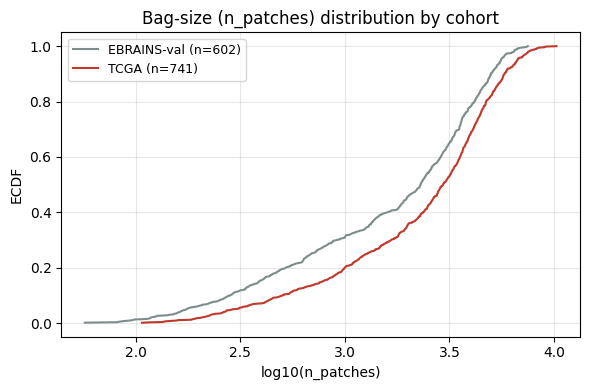


EBRAINS bags are systematically smaller than TCGA bags (median 2271 vs 2860). Extreme-percentile aggregates (top5_mean/p95/p99) are reported only as sensitivity checks in Section 7e, never as the primary discrimination number.


In [ ]:
bagsize = scores[["case_id", "encoder", "fold", "dataset", "n_patches"]].copy()

bagsize_summary = (
    bagsize.drop_duplicates(subset=["case_id", "dataset"])
    .groupby("dataset")["n_patches"]
    .describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)
display(bagsize_summary.round(1))

tcga_hash_fold = {
    cid: stable_seed("bagsize_hash", cid) % 5
    for cid in bagsize.loc[bagsize.dataset == "tcga", "case_id"].unique()
}
def _is_hash_row(row):
    if row["dataset"] == "ebrains":
        return True
    return row["fold"] == tcga_hash_fold[row["case_id"]]

bs_hash = bagsize[bagsize.apply(_is_hash_row, axis=1)].drop_duplicates(subset=["case_id", "encoder"])

bagsize_auroc_rows = []
for enc, g in bs_hash.groupby("encoder"):
    y = (g["dataset"] == "tcga").astype(int)
    m = binary_ood_metrics(y, g["n_patches"])
    ks = ks_two_sample(g.loc[g.dataset == "ebrains", "n_patches"], g.loc[g.dataset == "tcga", "n_patches"])
    bagsize_auroc_rows.append({"encoder": enc, "fold_policy": "hash_single", **m, **ks})
bagsize_comparison = pd.DataFrame(bagsize_auroc_rows)
display(bagsize_comparison.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
for dataset, label, color in [("ebrains", "EBRAINS-val", "#7f8c8d"), ("tcga", "TCGA", "#c0392b")]:
    x = np.sort(np.log10(bagsize.loc[bagsize.dataset == dataset, "n_patches"].drop_duplicates()))
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=f"{label} (n={len(x)})", color=color, lw=1.5)
ax.set_xlabel("log10(n_patches)"); ax.set_ylabel("ECDF")
ax.set_title("Bag-size (n_patches) distribution by cohort")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nEBRAINS bags are systematically smaller than TCGA bags (median "
      f"{bagsize_summary.loc['ebrains','50%']:.0f} vs {bagsize_summary.loc['tcga','50%']:.0f}). "
      "Extreme-percentile aggregates (top5_mean/p95/p99) are reported only as sensitivity "
      "checks in Section 7e, never as the primary discrimination number.")
bagsize_comparison.to_csv(OUT_DIR / "bagsize_comparison.csv", index=False)

Section 8's subgroup analysis needs to know, before it runs, which
variables exist in which cohort. Some (`tumour_type`, `idh_status`,
`sex`, `age`) are present in both and support a within-subgroup
EBRAINS-vs-TCGA AUROC; others (`site`, `objective_power`, `model`,
`race`, `mpp_x`) exist only for TCGA and support only a TCGA-side
stratification with the EBRAINS reference held fixed; `grade` exists
only for EBRAINS. Conflating these two designs would produce a
meaningless number.

Tabulates non-null coverage for every candidate subgroup column by
cohort, and flags any column that is constant (zero information) so it
can be excluded up front rather than spending a hypothesis test on it.

In [6]:
CANDIDATE_SUBGROUP_COLS = [
    "tumour_type", "idh_status", "sex", "age", "grade",
    "race", "site", "objective_power", "model", "mpp_x", "vendor",
    "idh_codel", "brain_region", "n_dx_slides_total",
]

avail_rows = []
for col in CANDIDATE_SUBGROUP_COLS:
    if col not in scores.columns:
        avail_rows.append({"variable": col, "in_ebrains": 0, "in_tcga": 0,
                            "n_unique_ebrains": 0, "n_unique_tcga": 0, "constant": None,
                            "note": "column not present"})
        continue
    eb = scores.loc[scores.dataset == "ebrains", col]
    tg = scores.loc[scores.dataset == "tcga", col]
    is_constant = (tg.dropna().nunique() <= 1) and (tg.notna().any())
    avail_rows.append({
        "variable": col,
        "in_ebrains": int(eb.notna().sum()), "in_tcga": int(tg.notna().sum()),
        "n_unique_ebrains": int(eb.dropna().nunique()), "n_unique_tcga": int(tg.dropna().nunique()),
        "constant": bool(is_constant),
        "note": "CONSTANT -- excluded from analysis" if is_constant else "",
    })
variable_availability = pd.DataFrame(avail_rows)
display(variable_availability)
variable_availability.to_csv(OUT_DIR / "variable_availability.csv", index=False)

BOTH_COHORT_VARS = [r["variable"] for r in avail_rows
                    if r["in_ebrains"] > 0 and r["in_tcga"] > 0 and not r["constant"]]
TCGA_ONLY_VARS = [r["variable"] for r in avail_rows
                  if r["in_ebrains"] == 0 and r["in_tcga"] > 0 and not r["constant"]]
print("Present in both cohorts (Section 8a design):", BOTH_COHORT_VARS)
print("TCGA-only (Section 8b design):              ", TCGA_ONLY_VARS)
print("Dropped as constant/absent:                  ",
      [r["variable"] for r in avail_rows if r["constant"] or (r["in_ebrains"] == 0 and r["in_tcga"] == 0)])

,variable,in_ebrains,in_tcga,n_unique_ebrains,n_unique_tcga,constant,note
0,tumour_type,1923,11835,3,4,False,
1,idh_status,1923,11835,2,2,False,
2,sex,1920,11835,2,3,False,
3,age,1911,11820,72,72,False,
4,grade,1923,0,3,0,False,
5,race,0,11835,0,6,False,
6,site,0,11835,0,34,False,
7,objective_power,0,11835,0,2,False,
8,model,0,11550,0,18,False,
9,mpp_x,0,11835,0,23,False,


Present in both cohorts (Section 8a design): ['tumour_type', 'idh_status', 'sex', 'age']
TCGA-only (Section 8b design):               ['race', 'site', 'objective_power', 'model', 'mpp_x', 'idh_codel', 'n_dx_slides_total']
Dropped as constant/absent:                   ['vendor', 'brain_region']


## 3. Leakage and split-integrity re-verification

The training script (`train_class_conditional_density.py`) already
enforces train/val disjointness at training time via
`validate_split_integrity`, which raises `RuntimeError` on any overlap, a
guarantee that can be trusted, not re-derived from scratch. What's
checked here is different: an independent re-derivation from the
checkpoints alone that the guarantee actually holds for the specific 15
checkpoints this notebook depends on, and that the cached scores in
`all_case_scores.csv` were in fact scored against the correct held-out
set.

`audit_split_integrity` loads only the `train_patients`/`val_patients`
lists from each of the 15 checkpoints (no model is reconstructed) and
checks, per (encoder, fold): train/val disjointness, that the two sets
sum to all 641 EBRAINS patients, and that the cached EBRAINS `case_id`s
for that (encoder, fold) match `val_patients` exactly. Per-encoder, it
additionally checks that the five folds' val sets partition all 641
patients with multiplicity exactly 1, and that no TCGA case ever appears
in any fold's `train_patients`.

In [7]:
def find_checkpoint(encoder, fold):
    root = BASE / "outputs/class_conditional_density" / encoder / f"fold{fold}"
    cands = sorted(root.glob("*/best.ckpt"))
    if not cands:
        raise FileNotFoundError(f"No density checkpoint under {root}")
    return cands[-1]


def audit_split_integrity(scores_df, encoders=ENCODERS, folds=FOLDS):
    import torch
    rows = []
    for enc in encoders:
        fold_train, fold_val = {}, {}
        for fold in folds:
            ckpt = torch.load(find_checkpoint(enc, fold), map_location="cpu", weights_only=False)
            train_p = set(map(str, ckpt["train_patients"]))
            val_p = set(map(str, ckpt["val_patients"]))
            fold_train[fold], fold_val[fold] = train_p, val_p

            cached_val_ids = set(scores_df.loc[
                (scores_df.encoder == enc) & (scores_df.dataset == "ebrains") & (scores_df.fold == fold),
                "case_id"])

            rows.append({"encoder": enc, "fold": fold, "check": "train_val_disjoint",
                        "passed": len(train_p & val_p) == 0})
            rows.append({"encoder": enc, "fold": fold, "check": "train_plus_val_eq_641",
                        "passed": (len(train_p) + len(val_p)) == 641})
            rows.append({"encoder": enc, "fold": fold, "check": "cached_ebrains_ids_eq_val_patients",
                        "passed": cached_val_ids == val_p})

        union_val = set().union(*fold_val.values())
        multiplicity = {p: sum(p in fold_val[f] for f in folds) for p in union_val}
        rows.append({"encoder": enc, "fold": -1, "check": "val_folds_partition_641_with_multiplicity_1",
                    "passed": len(union_val) == 641 and all(m == 1 for m in multiplicity.values())})

        tcga_ids = set(scores_df.loc[(scores_df.encoder == enc) & (scores_df.dataset == "tcga"), "case_id"])
        no_leak = all(len(tcga_ids & fold_train[f]) == 0 for f in folds)
        rows.append({"encoder": enc, "fold": -1, "check": "no_tcga_case_in_any_train_patients",
                    "passed": no_leak})
    return pd.DataFrame(rows)

split_integrity_audit = audit_split_integrity(scores)

def _highlight_fail(row):
    return ["background-color: #c0392b; color: white" if not row["passed"] else "" for _ in row]

display(split_integrity_audit.style.apply(_highlight_fail, axis=1))

n_fail = int((~split_integrity_audit["passed"]).sum())
if n_fail:
    print(f"*** {n_fail} check(s) FAILED -- see highlighted rows above. ***")
    display(split_integrity_audit[~split_integrity_audit["passed"]])
else:
    print(f"All {len(split_integrity_audit)} split-integrity checks passed across "
          f"{len(ENCODERS)} encoders x {len(FOLDS)} folds.")

split_integrity_audit.to_csv(OUT_DIR / "split_integrity_audit.csv", index=False)

,encoder,fold,check,passed
0,uni2,0,train_val_disjoint,True
1,uni2,0,train_plus_val_eq_641,True
2,uni2,0,cached_ebrains_ids_eq_val_patients,True
3,uni2,1,train_val_disjoint,True
4,uni2,1,train_plus_val_eq_641,True
5,uni2,1,cached_ebrains_ids_eq_val_patients,True
6,uni2,2,train_val_disjoint,True
7,uni2,2,train_plus_val_eq_641,True
8,uni2,2,cached_ebrains_ids_eq_val_patients,True
9,uni2,3,train_val_disjoint,True


All 51 split-integrity checks passed across 3 encoders x 5 folds.


## 4. The acquisition confound (read this before any performance number below)

Before any AUROC or statistical test appears, the design's biggest
limitation needs to be on the table: EBRAINS and TCGA were scanned on
different hardware, and that difference is not partial.

Joins `outputs/scanner_metadata/tcga_scanner_metadata.csv` (on
`case_id`) and `outputs/scanner_metadata/ebrains_scanner_metadata.csv`
(on `Path(filename).stem`, since the cached scores table has no
vendor/objective_power/mpp for EBRAINS rows, confirmed dropped as
"constant/absent" in Section 2d because they were entirely NaN there)
into one `acq` table, one row per (dataset, case_id).

In [8]:
def load_scanner_metadata():
    tcga_sm = pd.read_csv(BASE / "outputs/scanner_metadata/tcga_scanner_metadata.csv")
    tcga_sm["case_id"] = tcga_sm["case_id"].astype(str)
    tcga_sm = tcga_sm[["case_id", "vendor", "model", "objective_power", "mpp_x", "mpp_y"]].drop_duplicates("case_id")
    tcga_sm["dataset"] = "tcga"

    eb_sm = pd.read_csv(BASE / "outputs/scanner_metadata/ebrains_scanner_metadata.csv")
    eb_sm["case_id"] = eb_sm["filename"].apply(lambda f: Path(str(f)).stem)
    eb_sm = eb_sm[["case_id", "vendor", "model", "objective_power", "mpp_x", "mpp_y"]].drop_duplicates("case_id")
    eb_sm["dataset"] = "ebrains"

    ebrains_case_ids = set(scores.loc[scores.dataset == "ebrains", "case_id"].unique())
    join_rate = len(ebrains_case_ids & set(eb_sm["case_id"])) / len(ebrains_case_ids)
    print(f"EBRAINS scanner-metadata join rate: {join_rate:.4f} "
          f"({len(ebrains_case_ids & set(eb_sm['case_id']))}/{len(ebrains_case_ids)})")

    return pd.concat([tcga_sm, eb_sm], ignore_index=True)

acq = load_scanner_metadata()

site_by_case = (scores.loc[scores.dataset == "tcga", ["case_id", "site"]]
                .drop_duplicates("case_id"))
acq = acq.merge(site_by_case, on="case_id", how="left")

tumour_by_case = (scores[["case_id", "dataset", "tumour_type"]]
                  .drop_duplicates(["case_id", "dataset"]))
acq = acq.merge(tumour_by_case, on=["case_id", "dataset"], how="left", suffixes=("", "_dup"))
acq = acq.drop(columns=[c for c in acq.columns if c.endswith("_dup")])
print(f"acq shape: {acq.shape}")
acq.head(3)

EBRAINS scanner-metadata join rate: 1.0000 (641/641)
acq shape: (1431, 9)


,case_id,vendor,model,objective_power,mpp_x,mpp_y,dataset,site,tumour_type
0,TCGA-12-0819,aperio,PATH-MCLEN001MS,20,0.4993,0.4993,tcga,Duke,gbm
1,TCGA-HT-7473,aperio,SS1764CNTLR,40,0.2527,0.2527,tcga,Case Western - St Joes,astrocytoma
2,TCGA-26-6174,aperio,SS1436CNTLR,40,0.2485,0.2485,tcga,University of Florida,gbm


Cross-tabulates cohort against vendor and objective power, and
summarizes `mpp_x` per cohort, reporting the EBRAINS standard deviation
explicitly, since it is not merely small but numerically zero (a fixed
scan protocol).

In [9]:
acquisition_confound_table = pd.crosstab(acq["dataset"], acq["vendor"])
display(acquisition_confound_table)

print()
display(pd.crosstab(acq["dataset"], acq["objective_power"]))

print()
mpp_summary = acq.groupby("dataset")["mpp_x"].describe()[["count", "mean", "std", "min", "max"]]
display(mpp_summary)
print(f"\nEBRAINS mpp_x standard deviation = {mpp_summary.loc['ebrains','std']:.2e} "
      "-- effectively a single fixed value, not merely low-variance.")

acquisition_confound_table.to_csv(OUT_DIR / "acquisition_confound_table.csv")
mpp_summary.to_csv(OUT_DIR / "acquisition_mpp_summary.csv")

vendor,aperio,hamamatsu
dataset,,
ebrains,0,642
tcga,789,0


objective_power,20,40
dataset,,
ebrains,0,642
tcga,168,621


,count,mean,std,min,max
dataset,,,,,
ebrains,642.0,0.227811,2.777722e-17,0.227811,0.227811
tcga,789.0,0.304578,1.023819e-01,0.245600,0.504000



EBRAINS mpp_x standard deviation = 2.78e-17 -- effectively a single fixed value, not merely low-variance.


Pairwise Cramer's V among `dataset`, `vendor`, `objective_power`,
`site`, `model`, `tumour_type`, descriptive and deliberately uncorrected
(Section 1a). V(dataset, vendor) is expected to be exactly 1.0.

In [10]:
confound_pairs = [
    ("dataset", "vendor"), ("dataset", "objective_power"), ("dataset", "tumour_type"),
    ("vendor", "objective_power"), ("objective_power", "tumour_type"),
]
confound_rows = []
for a, b in confound_pairs:
    v, p, n = cramers_v(acq[a], acq[b])
    confound_rows.append({"var_a": a, "var_b": b, "cramers_v": v, "p": p, "n": n})
confound_cramers_v = pd.DataFrame(confound_rows)

def _flag_v1(row):
    return ["background-color: #c0392b; color: white" if row["cramers_v"] >= 0.99 else "" for _ in row]
display(confound_cramers_v.round(4).style.apply(_flag_v1, axis=1))

v_dv = confound_cramers_v.loc[
    (confound_cramers_v.var_a == "dataset") & (confound_cramers_v.var_b == "vendor"), "cramers_v"
].iloc[0]
assert v_dv >= 0.999, f"expected V(dataset,vendor)=1.0, got {v_dv}"
confound_cramers_v.to_csv(OUT_DIR / "confound_cramers_v.csv", index=False)

,var_a,var_b,cramers_v,p,n
0,dataset,vendor,1.000000,0.000000,1431
1,dataset,objective_power,0.329000,0.000000,1431
2,dataset,tumour_type,0.189800,0.000000,1430
3,vendor,objective_power,0.329000,0.000000,1431
4,objective_power,tumour_type,0.308200,0.000000,1430


## 5. Mahalanobis baseline: new GPU scoring

The Mahalanobis-distance ablation currently exists only for TCGA
(`outputs/selective_prediction_bench/master_patient_table.csv`'s
`ood_maha_*` columns), aggregated with ABMIL attention weights that
don't generalize to EBRAINS. Comparing it head-to-head against the flow
detector's EBRAINS-vs-TCGA AUROC needs scoring on EBRAINS-val too, with
the same percentile-based aggregation the flow scores use, computed from
scratch here.

Design choices: only the checkpoint's frozen projection weight and
latent normalizer buffers are needed, not the flows, so a lightweight
loader reads them directly out of the raw state dict without
reconstructing `ClassConditionalPatchDensityModel` or importing the flow
classes at all. The model applies `z = (z - latent_mean) / latent_std`
after projection when the normalizer was fitted; the existing TCGA-only
Mahalanobis code in `selective_prediction_bench_clean.ipynb` skips this.
It's applied here, and its effect on the resulting distances is verified
to be purely a numerical-conditioning device, not a substantive change
(Section 5c), since Mahalanobis distance is exactly affine-invariant
when the covariance is estimated on the identically-transformed
reference set. The EBRAINS-train reference fit is accumulated as
per-class sufficient statistics (count, sum, raw scatter matrix in the
64-d latent) rather than concatenating ~1.2M raw feature vectors per
fold into memory, exactly reproducing a batch fit (verified in 5c) at a
fraction of the memory footprint. Loop order is encoder, case,
fold-inner: all 5 folds' projections and fitted Gaussians for one
encoder are held resident simultaneously, so every `.h5` file is read
from disk once, not once per fold. No bag subsampling is used, since the
flow scores being compared against used every patch.

Three score families computed in one pass per patch: `maha`
(shared/pooled covariance, nearest-class distance, primary, matched to
the bench notebook's default), `mahapc` (per-class covariance,
sensitivity), `mahaenergy` (Gaussian mixture analogue of the flow's
`energy_ood`, using the checkpoint's own `class_log_prior`, so
`flow_energy_ood - mahaenergy` isolates the value of flow flexibility
over a closed-form Gaussian). Plus `featnorm` (mean L2 norm of the raw,
unprojected patch embeddings) as a free by-product and the strongest
available trivial baseline.

In [ ]:
import torch

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEVICE = get_device()
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


def load_projection_and_prior(encoder, fold):
    ckpt = torch.load(find_checkpoint(encoder, fold), map_location="cpu", weights_only=False)
    sd = ckpt["model_state"]
    return {
        "proj_weight": sd["encoder.linear.weight"].float(),    
        "latent_mean": sd["latent_mean"].float(),
        "latent_std": sd["latent_std"].float(),
        "normalizer_fitted": bool(sd["latent_normalizer_fitted"].item()),
        "class_log_prior": sd["class_log_prior"].float().numpy(),
        "train_patients": set(map(str, ckpt["train_patients"])),
        "val_patients": set(map(str, ckpt["val_patients"])),
        "in_dim": int(ckpt["in_dim"]),
        "latent_dim": int(ckpt["latent_dim"]),
    }


def make_projector(meta, device, apply_latent_norm=True):
    W = meta["proj_weight"].to(device)          
    mean = meta["latent_mean"].to(device)
    std = meta["latent_std"].to(device)
    use_norm = apply_latent_norm and meta["normalizer_fitted"]

    def project(feats_np, chunk=PROJ_CHUNK):
        out = []
        with torch.no_grad():
            for s in range(0, len(feats_np), chunk):
                x = torch.from_numpy(feats_np[s:s + chunk]).float().to(device)
                z = x @ W.T
                if use_norm:
                    z = (z - mean) / std
                out.append(z.detach().cpu().numpy())
        return np.concatenate(out, axis=0).astype(np.float64)

    return project


def read_feats(h5_path):
    with h5py.File(h5_path, "r") as f:
        if "feats" not in f:
            return None
        feats = f["feats"][:]
    return feats if len(feats) else None


print("Projection/loader helpers defined.")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
Projection/loader helpers defined.


`ClassAccumulator` holds per-class `(n, sum, raw scatter)` sufficient
statistics in the 64-d latent space; `finalize_class_gaussians` turns
those into class means and precisions, with `shared_cov=True`
reproducing exactly the bench notebook's pooled/LDA-style covariance and
`shared_cov=False` giving the per-class-covariance sensitivity variant,
both computed from the same accumulated statistics.
`maha_class_distances` gives the full per-class squared-Mahalanobis-
distance matrix once; `maha_patch_score` (nearest-class distance) and
`gaussian_energy_score` (mixture log-density under the fitted prior) are
both derived from it so the distance computation is shared rather than
duplicated.

In [ ]:
class ClassAccumulator:
    def __init__(self, n_classes, latent_dim):
        self.n_classes = n_classes
        self.n = np.zeros(n_classes, dtype=np.int64)
        self.sum_ = np.zeros((n_classes, latent_dim), dtype=np.float64)
        self.scatter = np.zeros((n_classes, latent_dim, latent_dim), dtype=np.float64)

    def add(self, z, class_idx):
        z = np.asarray(z, dtype=np.float64)
        self.n[class_idx] += len(z)
        self.sum_[class_idx] += z.sum(axis=0)
        self.scatter[class_idx] += z.T @ z


def finalize_class_gaussians(acc, shared_cov=True, eps=COV_EPS):
    d = acc.sum_.shape[1]
    means, centered_scatter = {}, {}
    for c in range(acc.n_classes):
        if acc.n[c] == 0:
            continue
        mean_c = acc.sum_[c] / acc.n[c]
        means[c] = mean_c
        centered_scatter[c] = acc.scatter[c] - acc.n[c] * np.outer(mean_c, mean_c)

    total_n = int(acc.n.sum())
    if shared_cov:
        pooled = sum(centered_scatter.values())
        cov = pooled / total_n + eps * np.eye(d)
        prec = np.linalg.inv(cov)
        precisions = {c: prec for c in means}
    else:
        precisions = {}
        for c in means:
            cov_c = centered_scatter[c] / acc.n[c] + eps * np.eye(d)
            precisions[c] = np.linalg.inv(cov_c)
    return means, precisions


def logdet_per_class(precisions):
    out = {}
    for c, prec in precisions.items():
        sign, logdet_prec = np.linalg.slogdet(prec)
        out[c] = float(-logdet_prec)
    return out


def maha_class_distances(feats_z, means, precisions):
    classes = sorted(means.keys())
    dists = np.empty((len(feats_z), len(classes)))
    for j, c in enumerate(classes):
        diff = feats_z - means[c]
        dists[:, j] = np.einsum("ij,jk,ik->i", diff, precisions[c], diff)
    return dists, classes


def maha_patch_score(class_dists):
    return class_dists.min(axis=1)


def gaussian_energy_score(class_dists, classes, logdet, class_log_prior, latent_dim):
    const = -0.5 * latent_dim * np.log(2 * np.pi)
    logdet_arr = np.array([logdet[c] for c in classes])
    log_n = const - 0.5 * logdet_arr[None, :] - 0.5 * class_dists          # [n, K]
    prior_arr = np.array([class_log_prior[c] for c in classes])
    joint = log_n + prior_arr[None, :]
    m = joint.max(axis=1, keepdims=True)
    lse = m[:, 0] + np.log(np.exp(joint - m).sum(axis=1))
    return -lse


def top_fraction_mean(values, fraction=0.05):
    n_top = max(1, int(math.ceil(len(values) * fraction)))
    partitioned = np.partition(values, len(values) - n_top)
    return float(partitioned[-n_top:].mean())


def aggregate_patch_scores(values, prefix, full=True):
    values = np.asarray(values, dtype=np.float64)
    out = {f"{prefix}_mean": float(values.mean())}
    if full:
        out[f"{prefix}_std"] = float(values.std())
        out[f"{prefix}_median"] = float(np.median(values))
        out[f"{prefix}_p90"] = float(np.quantile(values, 0.90))
        out[f"{prefix}_p95"] = float(np.quantile(values, 0.95))
        out[f"{prefix}_p99"] = float(np.quantile(values, 0.99))
        out[f"{prefix}_top5_mean"] = top_fraction_mean(values, 0.05)
    else:
        out[f"{prefix}_p95"] = float(np.quantile(values, 0.95))
        out[f"{prefix}_top5_mean"] = top_fraction_mean(values, 0.05)
    return out


print("Gaussian-fitting and scoring helpers defined.")

Gaussian-fitting and scoring helpers defined.


`build_ebrains_maps` reads each EBRAINS case's feature path and tumour
class directly from the already-loaded `scores` table (verified in
Section 2: 0/1/2 = gbm/astrocytoma/oligodendroglioma, matching
`CLASS_NAMES` order), no separate clinical-CSV lookup needed.
`fit_fold_references` then makes one pass over the 641 EBRAINS `.h5`
files per encoder: each patient's raw features are projected through all
5 folds' projections at once and accumulated into whichever folds'
accumulators have that patient in `train_patients` (up to 4 of the 5,
since 5-fold CV holds each patient out exactly once).

In [13]:
def build_ebrains_maps(scores_df, encoder):
    eb = scores_df[(scores_df.dataset == "ebrains") & (scores_df.encoder == encoder)].drop_duplicates("case_id")
    path_by_patient = eb.set_index("case_id")["feature_path"].to_dict()
    class_by_patient = {
        pid: int(c) for pid, c in eb.set_index("case_id")["tumour_class"].to_dict().items()
        if pd.notna(c)
    }
    return path_by_patient, class_by_patient


def fit_fold_references(encoder, folds, path_by_patient, class_by_patient, device,
                        apply_latent_norm=True, verbose=True):
    metas = {f: load_projection_and_prior(encoder, f) for f in folds}
    projectors = {f: make_projector(metas[f], device, apply_latent_norm=apply_latent_norm) for f in folds}
    latent_dim = metas[folds[0]]["latent_dim"]
    accs = {f: ClassAccumulator(NUM_CLASSES, latent_dim) for f in folds}
    contributing_patients = {f: set() for f in folds}

    n_dropped, dropped_ids = 0, []
    for pid, h5path in path_by_patient.items():
        cls = class_by_patient.get(pid)
        feats = None
        if cls is not None:
            feats = read_feats(Path(h5path))
        if cls is None or feats is None:
            n_dropped += 1; dropped_ids.append(pid); continue
        for f in folds:
            if pid in metas[f]["train_patients"]:
                z = projectors[f](feats)
                accs[f].add(z, cls)
                contributing_patients[f].add(pid)

    fold_models, report_rows = {}, []
    for f in folds:
        means_s, prec_s = finalize_class_gaussians(accs[f], shared_cov=True)
        means_p, prec_p = finalize_class_gaussians(accs[f], shared_cov=False)
        logdet_s = logdet_per_class(prec_s)
        logdet_p = logdet_per_class(prec_p)
        fold_models[f] = {
            "projector": projectors[f], "meta": metas[f],
            "means_shared": means_s, "prec_shared": prec_s, "logdet_shared": logdet_s,
            "means_pc": means_p, "prec_pc": prec_p, "logdet_pc": logdet_p,
            "class_log_prior": metas[f]["class_log_prior"], "latent_dim": latent_dim,
        }
        cond = float(np.linalg.cond(np.linalg.inv(prec_s[next(iter(prec_s))])))
        row = {"encoder": encoder, "fold": f, "n_ref_patients": len(contributing_patients[f]),
               "n_ref_patches_total": int(accs[f].n.sum()), "pooled_cov_condition_number": cond}
        for c, name in enumerate(CLASS_NAMES):
            row[f"n_ref_patches_{name}"] = int(accs[f].n[c])
        report_rows.append(row)
        if verbose:
            print(f"  [{encoder} fold{f}] ref patients={len(contributing_patients[f])} "
                  f"patches={int(accs[f].n.sum())} cond={cond:.2e}")

    ref_report = pd.DataFrame(report_rows)
    ref_report["n_dropped_patients"] = n_dropped
    return fold_models, ref_report, dropped_ids


print("Reference-fitting driver defined.")

Reference-fitting driver defined.


Three assertions must pass before this scoring pipeline is trusted
downstream. All three are run on `uni2` fold 0 only (representative, and
cheap enough to run inline rather than as part of the full scoring
loop).

In [14]:
VERIFY_ENCODER, VERIFY_FOLD = "uni2", 0
_verify_path_by_patient, _verify_class_by_patient = build_ebrains_maps(scores, VERIFY_ENCODER)
_verify_meta = load_projection_and_prior(VERIFY_ENCODER, VERIFY_FOLD)
_verify_train_ids = sorted(_verify_meta["train_patients"])[:40]   # small subsample, both assertions reuse it

_verify_feats_by_pid, _verify_cls_by_pid = {}, {}
for pid in _verify_train_ids:
    cls = _verify_class_by_patient.get(pid)
    feats = read_feats(Path(_verify_path_by_patient[pid])) if pid in _verify_path_by_patient and cls is not None else None
    if cls is not None and feats is not None:
        _verify_feats_by_pid[pid] = feats
        _verify_cls_by_pid[pid] = cls
print(f"Verification subsample: {len(_verify_feats_by_pid)} patients "
      f"({sum(len(f) for f in _verify_feats_by_pid.values())} patches)")

Verification subsample: 40 patients (76639 patches)


In [15]:
# --- Assertion 1: streaming sufficient statistics == naive batch fit -----------------
_verify_projector = make_projector(_verify_meta, DEVICE, apply_latent_norm=True)

_acc_stream = ClassAccumulator(NUM_CLASSES, _verify_meta["latent_dim"])
for pid, feats in _verify_feats_by_pid.items():
    _acc_stream.add(_verify_projector(feats), _verify_cls_by_pid[pid])
_means_stream, _prec_stream = finalize_class_gaussians(_acc_stream, shared_cov=True)

_z_by_class = {c: [] for c in range(NUM_CLASSES)}
for pid, feats in _verify_feats_by_pid.items():
    _z_by_class[_verify_cls_by_pid[pid]].append(_verify_projector(feats))
_z_by_class = {c: np.concatenate(v, axis=0) for c, v in _z_by_class.items() if v}

_means_batch = {c: z.mean(axis=0) for c, z in _z_by_class.items()}
_d = _verify_meta["latent_dim"]
_pooled_batch = np.zeros((_d, _d))
_total_n = sum(len(z) for z in _z_by_class.values())
for c, z in _z_by_class.items():
    r = z - _means_batch[c]
    _pooled_batch += r.T @ r
_prec_batch = np.linalg.inv(_pooled_batch / _total_n + COV_EPS * np.eye(_d))

_mean_diff = max(np.abs(_means_stream[c] - _means_batch[c]).max() for c in _means_batch)
_prec_diff = np.abs(_prec_stream[next(iter(_means_batch))] - _prec_batch).max()
_prec_scale = np.abs(_prec_batch).max()
print(f"[1] streaming-vs-batch: max mean abs diff = {_mean_diff:.2e}, "
      f"max precision abs diff = {_prec_diff:.2e} (relative to scale {_prec_scale:.2e})")
assert _mean_diff < 1e-8, "streaming means diverge from batch fit"
assert _prec_diff / _prec_scale < 1e-5, "streaming precision diverges from batch fit"
print("    PASSED")

[1] streaming-vs-batch: max mean abs diff = 0.00e+00, max precision abs diff = 6.88e-15 (relative to scale 2.44e+00)
    PASSED


In [ ]:
_projector_norm = make_projector(_verify_meta, DEVICE, apply_latent_norm=True)
_projector_raw = make_projector(_verify_meta, DEVICE, apply_latent_norm=False)

_acc_norm = ClassAccumulator(NUM_CLASSES, _d)
_acc_raw = ClassAccumulator(NUM_CLASSES, _d)
for pid, feats in _verify_feats_by_pid.items():
    _acc_norm.add(_projector_norm(feats), _verify_cls_by_pid[pid])
    _acc_raw.add(_projector_raw(feats), _verify_cls_by_pid[pid])
_means_norm, _prec_norm = finalize_class_gaussians(_acc_norm, shared_cov=True)
_means_raw, _prec_raw = finalize_class_gaussians(_acc_raw, shared_cov=True)

_test_pid = next(iter(_verify_feats_by_pid))
_test_feats = _verify_feats_by_pid[_test_pid]
_dists_norm, _classes = maha_class_distances(_projector_norm(_test_feats), _means_norm, _prec_norm)
_dists_raw, _ = maha_class_distances(_projector_raw(_test_feats), _means_raw, _prec_raw)
_score_norm = maha_patch_score(_dists_norm)
_score_raw = maha_patch_score(_dists_raw)

_abs_diff = np.abs(_score_norm - _score_raw).max()
_rel_diff = (_abs_diff / (np.abs(_score_raw).max() + 1e-12))
_rank_corr = float(np.corrcoef(np.argsort(np.argsort(_score_norm)), np.argsort(np.argsort(_score_raw)))[0, 1])
print(f"[2] affine invariance: max abs diff = {_abs_diff:.2e}, max rel diff = {_rel_diff:.2e}, "
      f"rank correlation = {_rank_corr:.10f}")
assert _rel_diff < 1e-4, "Mahalanobis distance not affine-invariant under the latent normalizer"
assert _rank_corr > 0.999999, "patch ranking changes under the latent normalizer"
print("    PASSED -- licenses comparing these numbers to the bench notebook's existing "
      "(un-normalized) TCGA-only ood_maha_* columns as a rough sanity check (Section 12).")

[2] affine invariance: max abs diff = 1.58e-03, max rel diff = 1.12e-05, rank correlation = 0.9999999954
    PASSED -- licenses comparing these numbers to the bench notebook's existing (un-normalized) TCGA-only ood_maha_* columns as a rough sanity check (Section 12).


In [ ]:
def maha_patch_score_torch(z, means, precisions, device):
    z_t = torch.from_numpy(z).double().to(device)
    classes = sorted(means.keys())
    dists = []
    for c in classes:
        mu = torch.from_numpy(means[c]).double().to(device)
        prec = torch.from_numpy(precisions[c]).double().to(device)
        diff = z_t - mu
        d = torch.einsum("ij,jk,ik->i", diff, prec, diff)
        dists.append(d)
    stacked = torch.stack(dists, dim=1)
    return stacked.min(dim=1).values.cpu().numpy()

_z_test = _projector_norm(_test_feats)
_score_np, _ = maha_class_distances(_z_test, _means_norm, _prec_norm)
_score_np = maha_patch_score(_score_np)
_score_gpu = maha_patch_score_torch(_z_test, _means_norm, _prec_norm, DEVICE)
_gpu_diff = np.abs(_score_np - _score_gpu).max()
print(f"[3] GPU-vs-numpy: max abs diff = {_gpu_diff:.2e}")
assert _gpu_diff < 1e-6, "GPU Mahalanobis distance diverges from numpy reference"
print("    PASSED")

del _acc_stream, _acc_norm, _acc_raw, _z_by_class, _verify_feats_by_pid

[3] GPU-vs-numpy: max abs diff = 6.54e-13
    PASSED


`build_scoring_index` mirrors the flow table's own row structure
exactly off `feature_path` (guaranteeing the identical slide is scored):
each EBRAINS-val case gets `folds_to_score = [its own held-out fold]`;
each TCGA case gets all 5. `score_slide_maha` reads one slide's features
once and, for every fold it needs to be scored under, projects through
that fold's projection and computes all three Mahalanobis-family scores
plus `featnorm`, so I/O happens once per case regardless of how many
folds it's scored under. `run_maha_scoring` is the resumable driver:
per-encoder partial CSVs (scores, reference report, runtime log) are
written to `_maha_partial/` and reloaded on restart instead of
recomputing.

In [18]:
import time

def build_scoring_index(scores_df, encoder, limit=None):
    sub = scores_df[scores_df.encoder == encoder]

    eb = sub[sub.dataset == "ebrains"].drop_duplicates("case_id")[
        ["case_id", "dataset", "feature_path", "n_patches", "fold"]].copy()
    eb["folds_to_score"] = eb["fold"].apply(lambda f: [int(f)])
    eb = eb.drop(columns=["fold"])

    tg = sub[sub.dataset == "tcga"].drop_duplicates("case_id")[
        ["case_id", "dataset", "feature_path", "n_patches"]].copy()
    tg["folds_to_score"] = [list(FOLDS) for _ in range(len(tg))]

    idx = pd.concat([eb, tg], ignore_index=True)
    if limit is not None:
        idx = pd.concat([idx[idx.dataset == "ebrains"].head(limit),
                          idx[idx.dataset == "tcga"].head(limit)], ignore_index=True)
    return idx


def score_slide_maha(feats, fold_models, folds_to_score):
    featnorm = np.linalg.norm(feats, axis=1)
    featnorm_agg = aggregate_patch_scores(featnorm, "featnorm", full=False)

    rows = []
    for f in folds_to_score:
        fm = fold_models[f]
        z = fm["projector"](feats)

        dists_shared, classes_shared = maha_class_distances(z, fm["means_shared"], fm["prec_shared"])
        maha_score = maha_patch_score(dists_shared)
        energy_score = gaussian_energy_score(
            dists_shared, classes_shared, fm["logdet_shared"], fm["class_log_prior"], fm["latent_dim"])

        dists_pc, _ = maha_class_distances(z, fm["means_pc"], fm["prec_pc"])
        mahapc_score = maha_patch_score(dists_pc)

        row = {"fold": f, "n_patches": len(feats)}
        row.update(aggregate_patch_scores(maha_score, "maha", full=True))
        row.update(aggregate_patch_scores(mahapc_score, "mahapc", full=False))
        row.update(aggregate_patch_scores(energy_score, "mahaenergy", full=False))
        row.update(featnorm_agg)
        rows.append(row)
    return rows


def run_maha_scoring(scores_df, encoders=ENCODERS, folds=FOLDS, device=DEVICE,
                     checkpoint_every=100, resume=True, limit=None):
    all_scores, all_ref_reports, all_runtime = [], [], []

    for enc in encoders:
        idx = build_scoring_index(scores_df, enc, limit=limit)
        expected_n = int(idx["folds_to_score"].apply(len).sum())

        scores_partial = PARTIAL_DIR / f"{enc}_scores.csv"
        ref_partial = PARTIAL_DIR / f"{enc}_ref_report.csv"
        runtime_partial = PARTIAL_DIR / f"{enc}_runtime.csv"

        if resume and limit is None and scores_partial.exists() and ref_partial.exists() and runtime_partial.exists():
            cached = pd.read_csv(scores_partial)
            if len(cached) == expected_n:
                print(f"[{enc}] cached partial complete ({len(cached)} rows) -- skipping")
                all_scores.append(cached)
                all_ref_reports.append(pd.read_csv(ref_partial))
                all_runtime.append(pd.read_csv(runtime_partial))
                continue
            print(f"[{enc}] cached partial incomplete ({len(cached)}/{expected_n}) -- rescoring")

        print(f"[{enc}] fitting fold references from EBRAINS-train...")
        path_by_patient, class_by_patient = build_ebrains_maps(scores_df, enc)
        t0 = time.time()
        fold_models, ref_report, dropped_ids = fit_fold_references(
            enc, folds, path_by_patient, class_by_patient, device, verbose=False)
        t_ref = time.time() - t0
        if dropped_ids:
            print(f"  [{enc}] dropped {len(dropped_ids)} reference patient(s): {dropped_ids[:5]}")
        ref_report.to_csv(ref_partial, index=False)
        all_ref_reports.append(ref_report)
        print(f"  [{enc}] reference fit done in {t_ref:.0f}s")

        print(f"[{enc}] scoring {len(idx)} cases ({expected_n} case-fold rows)...")
        rows, n_errors = [], 0
        t1 = time.time()
        for i, r in enumerate(idx.itertuples()):
            try:
                feats = read_feats(Path(r.feature_path))
                if feats is None:
                    raise RuntimeError("empty or missing feats")
                if len(feats) != r.n_patches:
                    raise RuntimeError(f"n_patches mismatch: h5 has {len(feats)}, table says {r.n_patches}")
                for sr in score_slide_maha(feats, fold_models, r.folds_to_score):
                    sr.update({"case_id": r.case_id, "encoder": enc, "dataset": r.dataset,
                               "maha_status": "ok", "maha_error": ""})
                    rows.append(sr)
            except Exception as e:
                n_errors += 1
                for f in r.folds_to_score:
                    rows.append({"case_id": r.case_id, "encoder": enc, "dataset": r.dataset, "fold": f,
                                 "n_patches": np.nan, "maha_status": "error", "maha_error": str(e)})
            if (i + 1) % checkpoint_every == 0 or (i + 1) == len(idx):
                pd.DataFrame(rows).to_csv(scores_partial, index=False)
                elapsed = time.time() - t1
                print(f"  [{enc}] {i + 1}/{len(idx)} cases, {len(rows)} rows, "
                      f"{elapsed:.0f}s elapsed, {(i + 1) / max(elapsed, 1e-9):.2f} cases/s, {n_errors} errors")

        t_score = time.time() - t1
        runtime_row = pd.DataFrame([{
            "encoder": enc, "n_ref_patients": int(ref_report["n_ref_patients"].sum()),
            "ref_fit_seconds": t_ref, "n_cases_scored": len(idx), "n_rows": len(rows),
            "scoring_seconds": t_score, "cases_per_second": len(idx) / max(t_score, 1e-9),
            "n_errors": n_errors,
        }])
        runtime_row.to_csv(runtime_partial, index=False)
        all_runtime.append(runtime_row)
        all_scores.append(pd.DataFrame(rows))
        del fold_models

    maha_df = pd.concat(all_scores, ignore_index=True)
    ref_report_all = pd.concat(all_ref_reports, ignore_index=True)
    runtime_log = pd.concat(all_runtime, ignore_index=True)
    return maha_df, ref_report_all, runtime_log


print("Scoring driver defined.")

Scoring driver defined.


All 3 encoders, all 5 folds, no case limit: 641 EBRAINS-val cases (1
fold each) + 789 TCGA cases (all 5 folds each) = 4,586 case-fold rows per
encoder, 13,758 total, matching the flow table's row count exactly.
Skipped entirely if the final cache already exists; otherwise each
encoder resumes from its own partial cache if present. This is the
expensive step in the notebook, dominated by `.h5` read I/O rather than
GPU compute (the smoke test above measured reference-fitting at
~70s/encoder, with case scoring fast enough that the full run is
expected to take on the order of 10-15 minutes per encoder).

In [ ]:
if MAHA_CSV.exists():
    maha = pd.read_csv(MAHA_CSV)
    print(f"Loaded cached {MAHA_CSV}, shape={maha.shape}")
else:
    maha, maha_ref_report, maha_runtime_log = run_maha_scoring(scores)
    n_bad = int((maha["maha_status"] != "ok").sum())
    if n_bad:
        print(f"WARNING: {n_bad} rows failed to score:")
        display(maha.loc[maha["maha_status"] != "ok", ["case_id", "encoder", "fold", "maha_error"]].head(20))
    assert len(maha) == 13758, f"expected 13758 rows, got {len(maha)}"
    maha.to_csv(MAHA_CSV, index=False)
    maha_ref_report.to_csv(OUT_DIR / "maha_reference_report.csv", index=False)
    maha_runtime_log.to_csv(OUT_DIR / "maha_runtime_log.csv", index=False)
    print(f"Saved {MAHA_CSV}, shape={maha.shape}")

display(maha_runtime_log if "maha_runtime_log" in dir() else pd.read_csv(OUT_DIR / "maha_runtime_log.csv"))
maha.head(3)

Loaded cached /cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_analysis/maha_case_scores.csv, shape=(13758, 23)


,encoder,n_ref_patients,ref_fit_seconds,n_cases_scored,n_rows,scoring_seconds,cases_per_second,n_errors
0,uni2,2564,52.278889,1430,4586,393.653538,3.632636,0
1,conch,2564,26.371166,1430,4586,256.439811,5.576357,0
2,hoptimus,2564,67.205170,1430,4586,378.727482,3.775802,0


,fold,n_patches,maha_mean,maha_std,maha_median,maha_p90,maha_p95,maha_p99,maha_top5_mean,mahapc_mean,mahapc_p95,mahapc_top5_mean,mahaenergy_mean,mahaenergy_p95,mahaenergy_top5_mean,featnorm_mean,featnorm_p95,featnorm_top5_mean,case_id,encoder,dataset,maha_status,maha_error
0,0,696,60.855870,15.672681,58.343123,81.260695,90.364907,106.754844,102.668003,61.152561,90.181929,103.167971,81.918996,97.056365,102.928835,15.967212,20.46875,21.390179,a197b70a-357f-11eb-81c9-001a7dda7111,uni2,ebrains,ok,NaN
1,0,312,74.994694,22.736160,73.290448,105.760802,115.436914,135.049757,125.760460,77.588947,121.290910,131.250656,89.572120,109.676464,114.867295,17.886168,20.71875,21.313477,a1963049-357f-11eb-85a4-001a7dda7111,uni2,ebrains,ok,NaN
2,0,3876,64.767556,22.251436,59.840501,91.990526,107.373377,143.886804,129.559696,65.715147,109.540823,130.470180,84.563833,105.629778,116.732128,17.499123,21.75000,22.990416,a197ddb9-357f-11eb-a415-001a7dda7111,uni2,ebrains,ok,NaN


Merges the new Mahalanobis-family scores onto the existing flow
scores, 1:1 on `(case_id, encoder, fold, dataset)`, and asserts
`n_patches` matches row-for-row between the two tables: proof that both
detectors were scored on the byte-identical patch set for every case,
which is what makes every delta-AUROC in Section 7 a clean ablation
rather than a confounded comparison.

In [20]:
merged = scores.merge(
    maha.drop(columns=["maha_status", "maha_error"]),
    on=["case_id", "encoder", "fold", "dataset"], how="inner",
    suffixes=("", "_maha"), validate="1:1")

assert len(merged) == 13758, f"merge dropped rows: {len(merged)} != 13758"
assert (merged["n_patches"] == merged["n_patches_maha"]).all(), \
    "n_patches mismatch between flow and Mahalanobis tables -- not scoring the same patches"
merged = merged.drop(columns=["n_patches_maha"])
print(f"Merged shape: {merged.shape}. n_patches identity confirmed -- both detectors "
      "scored the identical patch set for every one of the 13,758 rows.")

merged.to_csv(MERGED_CSV, index=False)
merged.head(3)

Merged shape: (13758, 83). n_patches identity confirmed -- both detectors scored the identical patch set for every one of the 13,758 rows.


,PATIENT,FILENAME,uuid,pat_id,diagnosis,grade,subtype,secondary_diagnosis,control,age,sex,location,laterality,cellularity,tissue_area,recurrence,comment,idh_status,tumour_type,location_parsed,is_cerebral,idh_binary,dataset,case_id,tumour_class,encoder,fold,feature_path,n_patches,ood_mean,...,tumour_type_who2021,race,site,n_dx_slides_total,idh_codel,vendor,model,objective_power,mpp_x,mpp_y,software,scan_date,size_mb_scanner,brain_region,maha_mean,maha_std,maha_median,maha_p90,maha_p95,maha_p99,maha_top5_mean,mahapc_mean,mahapc_p95,mahapc_top5_mean,mahaenergy_mean,mahaenergy_p95,mahaenergy_top5_mean,featnorm_mean,featnorm_p95,featnorm_top5_mean
0,a197b70a-357f-11eb-81c9-001a7dda7111,a197b70a-357f-11eb-81c9-001a7dda7111.h5,a197b70a-357f-11eb-81c9-001a7dda7111,256.0,"Glioblastoma, IDH-wildtype",IV,NaN,NaN,0.0,57.0,male,"['frontal', 'temporal']",right,7658.731631,33.210068,0.0,NaN,wildtype,gbm,"frontal, temporal",True,0.0,ebrains,a197b70a-357f-11eb-81c9-001a7dda7111,0.0,uni2,0,/cs/student/project_msc/2025/aibh/mpapageo/dat...,696,77.718903,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.855870,15.672681,58.343123,81.260695,90.364907,106.754844,102.668003,61.152561,90.181929,103.167971,81.918996,97.056365,102.928835,15.967212,20.46875,21.390179
1,a1963049-357f-11eb-85a4-001a7dda7111,a1963049-357f-11eb-85a4-001a7dda7111.h5,a1963049-357f-11eb-85a4-001a7dda7111,516.0,"Diffuse astrocytoma, IDH-wildtype",II,NaN,NaN,0.0,27.0,male,['cerebellar'],NaN,1660.601011,15.546781,0.0,NaN,wildtype,astrocytoma,cerebellar,False,0.0,ebrains,a1963049-357f-11eb-85a4-001a7dda7111,1.0,uni2,0,/cs/student/project_msc/2025/aibh/mpapageo/dat...,312,82.412231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.994694,22.736160,73.290448,105.760802,115.436914,135.049757,125.760460,77.588947,121.290910,131.250656,89.572120,109.676464,114.867295,17.886168,20.71875,21.313477
2,a197ddb9-357f-11eb-a415-001a7dda7111,a197ddb9-357f-11eb-a415-001a7dda7111.h5,a197ddb9-357f-11eb-a415-001a7dda7111,1852.0,"Anaplastic oligodendroglioma, IDH-mutant and 1...",III,NaN,NaN,0.0,54.0,male,['frontal'],right,7458.675982,238.664611,0.0,NaN,mutant,oligodendroglioma,frontal,True,1.0,ebrains,a197ddb9-357f-11eb-a415-001a7dda7111,2.0,uni2,0,/cs/student/project_msc/2025/aibh/mpapageo/dat...,3876,79.208572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.767556,22.251436,59.840501,91.990526,107.373377,143.886804,129.559696,65.715147,109.540823,130.470180,84.563833,105.629778,116.732128,17.499123,21.75000,22.990416


## 6. Trivial baselines and the aggregation-choice audit

A detector that has learned nothing about density except "TCGA slides
have more patches" would still look like a competent OOD detector under
AUROC. Two trivial baselines (`n_patches`, `featnorm`) are pushed through
the identical Section 7 machinery as the flow and Mahalanobis detectors,
as extra rows in every table, not as a side remark; if the pre-specified
detectors don't clear these by a wide margin, that undermines any claim
that they're detecting density.

Defines the detector/variant/column mapping every downstream section
reads from, builds the tidy long table (`case_id, encoder, fold,
dataset, detector, variant, score`), computes a permutation-null AUROC
distribution (its 97.5th percentile becomes a grey "significance floor"
line on every AUROC plot below), and runs the within-cohort
bag-size-sensitivity audit that is the empirical justification for
Section 1a's `*_mean`-as-primary pre-specification.

In [ ]:
DETECTOR_COLUMNS = {
    "flow_ood":    {"mean": "ood_mean", "std": "ood_std", "median": "ood_median",
                    "p90": "ood_p90", "p95": "ood_p95", "p99": "ood_p99", "top5_mean": "ood_top5_mean"},
    "flow_energy": {"mean": "energy_ood_mean", "p95": "energy_ood_p95"},
    "maha":        {"mean": "maha_mean", "std": "maha_std", "median": "maha_median",
                    "p90": "maha_p90", "p95": "maha_p95", "p99": "maha_p99", "top5_mean": "maha_top5_mean"},
    "mahapc":      {"mean": "mahapc_mean", "p95": "mahapc_p95", "top5_mean": "mahapc_top5_mean"},
    "mahaenergy":  {"mean": "mahaenergy_mean", "p95": "mahaenergy_p95", "top5_mean": "mahaenergy_top5_mean"},
    "n_patches":   {"raw": "n_patches"},
    "featnorm":    {"mean": "featnorm_mean", "p95": "featnorm_p95", "top5_mean": "featnorm_top5_mean"},
}

PRIMARY_VARIANT = {
    "flow_ood": "mean", "flow_energy": "mean", "maha": "mean",
    "mahapc": "mean", "mahaenergy": "mean", "n_patches": "raw", "featnorm": "mean",
}
PRIMARY_DETECTORS = ["flow_ood", "flow_energy", "maha", "n_patches", "featnorm"]      # Section 1a primary set
SENSITIVITY_DETECTORS = ["mahapc", "mahaenergy"]                                      # ablation/sensitivity only

for det, variants in DETECTOR_COLUMNS.items():
    missing = [c for c in variants.values() if c not in merged.columns]
    assert not missing, f"{det}: missing columns {missing}"
print("All detector/variant columns present in `merged`.")


def make_long(merged_df, detector_columns=DETECTOR_COLUMNS):
    id_cols = ["case_id", "encoder", "fold", "dataset"]
    frames = []
    for detector, variants in detector_columns.items():
        for variant, col in variants.items():
            f = merged_df[id_cols + [col]].copy()
            f["detector"], f["variant"] = detector, variant
            f["score"] = f[col].astype(float)
            frames.append(f[id_cols + ["detector", "variant", "score"]])
    return pd.concat(frames, ignore_index=True)

long = make_long(merged)
print(f"long shape: {long.shape} ({long['detector'].nunique()} detectors x "
      f"{long.groupby('detector')['variant'].nunique().sum()} detector-variant combos)")
long.head(3)

All detector/variant columns present in `merged`.
long shape: (357708, 7) (7 detectors x 26 detector-variant combos)


,case_id,encoder,fold,dataset,detector,variant,score
0,a197b70a-357f-11eb-81c9-001a7dda7111,uni2,0,ebrains,flow_ood,mean,77.718903
1,a1963049-357f-11eb-85a4-001a7dda7111,uni2,0,ebrains,flow_ood,mean,82.412231
2,a197ddb9-357f-11eb-a415-001a7dda7111,uni2,0,ebrains,flow_ood,mean,79.208572


The null distribution of a rank-based statistic like AUROC under a
random permutation of labels depends only on the two sample sizes, not
on the actual score values, so one permutation run (n_id=641, n_ood=789,
the sizes every `encoder` and `detector` share under the `hash_single`
policy) gives the significance floor for every AUROC reported anywhere
in Section 7 and Section 8, rather than needing to be recomputed per
detector.

In [22]:
def permutation_null_auroc(n_id, n_ood, n_perm=N_PERM, seed=0):
    rng = np.random.default_rng(seed)
    y = np.array([0] * n_id + [1] * n_ood)
    s = rng.random(n_id + n_ood)   # arbitrary continuous scores; only rank structure under
                                    # permutation matters, and permuting y makes score values irrelevant
    null = np.empty(n_perm)
    for i in range(n_perm):
        null[i] = roc_auc_score(rng.permutation(y), s)
    return null

N_EBRAINS_VAL, N_TCGA = 641, 789
auroc_null = permutation_null_auroc(N_EBRAINS_VAL, N_TCGA, seed=RNG_SEED)
AUROC_SIGNIFICANCE_FLOOR = float(np.quantile(auroc_null, 0.975))
print(f"Permutation-null AUROC: mean={auroc_null.mean():.4f} (expect ~0.500, a pipeline "
      f"correctness check), 97.5th percentile={AUROC_SIGNIFICANCE_FLOOR:.4f} "
      f"(n_id={N_EBRAINS_VAL}, n_ood={N_TCGA}, n_perm={N_PERM}).")
assert abs(auroc_null.mean() - 0.5) < 0.01, "permutation null AUROC mean far from 0.5 -- check pipeline"

Permutation-null AUROC: mean=0.5001 (expect ~0.500, a pipeline correctness check), 97.5th percentile=0.5298 (n_id=641, n_ood=789, n_perm=2000).


Spearman correlation between each detector-variant's score and
`n_patches`, computed within cohort (so the cohort's own bag-size
difference cannot manufacture the correlation), the direct empirical
test of Section 2c's concern that extreme-percentile aggregates are
confounded with bag size.

In [23]:
from scipy.stats import spearmanr

def bagsize_sensitivity(long_df, merged_df):
    npatch = merged_df[["case_id", "encoder", "fold", "dataset", "n_patches"]]
    m = long_df.merge(npatch, on=["case_id", "encoder", "fold", "dataset"])
    rows = []
    for (enc, det, var, ds), g in m.groupby(["encoder", "detector", "variant", "dataset"], observed=True):
        if len(g) < 10 or g["score"].nunique() < 2:
            continue
        rho, p = spearmanr(g["score"], g["n_patches"])
        rows.append({"encoder": enc, "detector": det, "variant": var, "dataset": ds,
                    "n": len(g), "spearman_rho": float(rho), "p": float(p)})
    return pd.DataFrame(rows)

bagsize_sensitivity_table = bagsize_sensitivity(long, merged)
bagsize_sensitivity_table.to_csv(OUT_DIR / "bagsize_sensitivity.csv", index=False)

primary_agg_check = bagsize_sensitivity_table[bagsize_sensitivity_table.variant.isin(["mean", "raw"])]
extreme_agg_check = bagsize_sensitivity_table[bagsize_sensitivity_table.variant.isin(["top5_mean", "p99", "p95"])]
print("Median |Spearman rho| with n_patches, primary aggregate (*_mean):",
      round(primary_agg_check["spearman_rho"].abs().median(), 3))
print("Median |Spearman rho| with n_patches, extreme aggregates (top5_mean/p95/p99):",
      round(extreme_agg_check["spearman_rho"].abs().median(), 3))

display(bagsize_sensitivity_table.reindex(
    bagsize_sensitivity_table["spearman_rho"].abs().sort_values(ascending=False).index
).head(15))

Median |Spearman rho| with n_patches, primary aggregate (*_mean): 0.17
Median |Spearman rho| with n_patches, extreme aggregates (top5_mean/p95/p99): 0.156


,encoder,detector,variant,dataset,n,spearman_rho,p
102,hoptimus,n_patches,raw,ebrains,641,1.000000,0.000000e+00
103,hoptimus,n_patches,raw,tcga,3945,1.000000,0.000000e+00
50,conch,n_patches,raw,ebrains,641,1.000000,0.000000e+00
51,conch,n_patches,raw,tcga,3945,1.000000,0.000000e+00
155,uni2,n_patches,raw,tcga,3945,1.000000,0.000000e+00
154,uni2,n_patches,raw,ebrains,641,1.000000,0.000000e+00
21,conch,flow_ood,std,tcga,3945,0.458633,1.741426e-204
20,conch,flow_ood,std,ebrains,641,0.423873,2.445278e-29
70,hoptimus,flow_ood,p99,ebrains,641,0.405082,1.041880e-26
74,hoptimus,flow_ood,top5_mean,ebrains,641,0.382461,9.298496e-24


Confirms mechanically, not just by convention, that no table built
from `long` averages a raw score across more than one encoder, since the
density model's own docstring states raw likelihood scales are
encoder-specific.

In [24]:
assert_no_cross_encoder_pooling(long, group_cols=["encoder", "detector", "variant", "dataset"])
assert_no_cross_encoder_pooling(long, group_cols=["encoder", "detector", "variant", "fold", "dataset"])
print("Confirmed safe: grouping with encoder included passes.")

try:
    assert_no_cross_encoder_pooling(long, group_cols=["detector", "variant", "dataset"])
    raise RuntimeError("expected AssertionError was not raised")
except AssertionError as e:
    print(f"Confirmed unsafe (correctly caught): {e}")

Confirmed safe: grouping with encoder included passes.
Confirmed unsafe (correctly caught): Grouping by ['detector', 'variant', 'dataset'] without 'encoder' pools 52 group(s) across more than one encoder's raw score scale.


## 7. EBRAINS-val vs. TCGA discrimination

This is the notebook's headline question, asked five different ways on
purpose: a per-fold breakdown (so the five, non-independent,
model-instability estimates are visible rather than silently averaged
away), a cluster-bootstrap headline number (the only defensible
confidence interval given Section 1b's fold-duplication policy), a
distributional test on an i.i.d. sample, a paired comparison against the
trivial baselines and between the flow and Mahalanobis families, and a
full sensitivity sweep over every aggregate variant rather than the one
arbitrary choice the old notebook made.

`per_fold_metrics` computes `binary_ood_metrics` + `ks_two_sample` for
every (encoder, fold, detector, variant) under the `per_fold` policy,
with a stratified bootstrap CI and `n_boot_dropped` logged explicitly.

In [25]:
def _stratified_boot_idx(y, rng):
    z, o = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(z, len(z), True), rng.choice(o, len(o), True)])


def bootstrap_auroc_ci(y, s, n_boot=N_BOOT_MAIN, seed=0):
    y = np.asarray(y, int); s = np.asarray(s, float)
    rng = np.random.default_rng(seed)
    vals, dropped = [], 0
    for _ in range(n_boot):
        idx = _stratified_boot_idx(y, rng)
        if len(np.unique(y[idx])) < 2:
            dropped += 1; continue
        vals.append(roc_auc_score(y[idx], s[idx]))
    vals = np.asarray(vals)
    lo, hi = (np.quantile(vals, [0.025, 0.975]) if len(vals) else (np.nan, np.nan))
    return float(lo), float(hi), int(len(vals)), int(dropped)


def per_fold_metrics(long_df, n_boot=N_BOOT_SUBGROUP):
    rows = []
    for (enc, fold, det, var), g in long_df.groupby(["encoder", "fold", "detector", "variant"], observed=True):
        y = (g["dataset"] == "tcga").astype(int).to_numpy()
        s = g["score"].to_numpy()
        m = binary_ood_metrics(y, s)
        ks = ks_two_sample(s[y == 0], s[y == 1])
        seed = stable_seed("per_fold", enc, fold, det, var)
        ci_lo, ci_hi, n_valid, n_dropped = bootstrap_auroc_ci(y, s, n_boot=n_boot, seed=seed)
        rows.append({"encoder": enc, "fold": fold, "detector": det, "variant": var,
                    "fold_policy": "per_fold", **m, **ks,
                    "auroc_ci_low": ci_lo, "auroc_ci_high": ci_hi,
                    "n_boot_valid": n_valid, "n_boot_dropped": n_dropped})
    return pd.DataFrame(rows)

# >>> DATA LOAD <<<
_per_fold_cache = OUT_DIR / "per_fold_discrimination.csv"
if _per_fold_cache.exists():
    per_fold_discrimination = pd.read_csv(_per_fold_cache)
    print(f"Loaded cached {_per_fold_cache}, shape={per_fold_discrimination.shape}")
else:
    per_fold_discrimination = per_fold_metrics(long)
    per_fold_discrimination.to_csv(_per_fold_cache, index=False)
    print(f"Saved {_per_fold_cache}, shape={per_fold_discrimination.shape}")
print(f"{len(per_fold_discrimination)} (encoder,fold,detector,variant) rows computed.")
display(per_fold_discrimination[
    (per_fold_discrimination.variant == "mean") | (per_fold_discrimination.variant == "raw")
].sort_values(["encoder", "detector", "fold"]).head(15).round(3))

Loaded cached /cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_analysis/per_fold_discrimination.csv, shape=(390, 23)
390 (encoder,fold,detector,variant) rows computed.


,encoder,fold,detector,variant,fold_policy,n_id,n_ood,auroc,auprc_ood_positive,auprc_id_positive,prevalence_ood,fpr_at_95_tpr,rank_biserial,cohens_d,variance_ratio,ks_stat,ks_p,ks_stat_location,ks_stat_sign,auroc_ci_low,auroc_ci_high,n_boot_valid,n_boot_dropped
0,conch,0,featnorm,mean,per_fold,129,789,0.449,0.851,0.119,0.859,0.992,-0.103,-0.190,1.462,0.118,0.082,22.651,-1.0,0.403,0.494,500,0
26,conch,1,featnorm,mean,per_fold,128,789,0.453,0.852,0.120,0.860,0.992,-0.095,-0.178,1.423,0.105,0.166,22.646,-1.0,0.403,0.503,500,0
52,conch,2,featnorm,mean,per_fold,128,789,0.506,0.877,0.131,0.860,0.984,0.012,0.008,1.783,0.100,0.207,22.647,-1.0,0.457,0.558,500,0
78,conch,3,featnorm,mean,per_fold,128,789,0.445,0.859,0.116,0.860,1.000,-0.111,-0.184,1.984,0.143,0.020,22.653,-1.0,0.397,0.495,500,0
104,conch,4,featnorm,mean,per_fold,128,789,0.453,0.852,0.122,0.860,0.992,-0.095,-0.168,1.316,0.117,0.088,22.652,-1.0,0.410,0.503,500,0
3,conch,0,flow_energy,mean,per_fold,129,789,0.708,0.935,0.397,0.859,0.682,0.416,0.838,0.968,0.282,0.000,43.520,1.0,0.660,0.753,500,0
29,conch,1,flow_energy,mean,per_fold,128,789,0.741,0.945,0.427,0.860,0.672,0.482,0.965,1.005,0.350,0.000,48.823,1.0,0.696,0.785,500,0
55,conch,2,flow_energy,mean,per_fold,128,789,0.696,0.931,0.377,0.860,0.742,0.392,0.781,0.939,0.291,0.000,50.897,1.0,0.650,0.747,500,0
81,conch,3,flow_energy,mean,per_fold,128,789,0.716,0.933,0.391,0.860,0.711,0.432,0.834,0.863,0.318,0.000,51.550,1.0,0.667,0.764,500,0
107,conch,4,flow_energy,mean,per_fold,128,789,0.707,0.931,0.364,0.860,0.758,0.414,0.787,1.033,0.286,0.000,47.084,1.0,0.660,0.753,500,0


The headline number: mean of the 5 `per_fold` AUROCs per (encoder,
detector, variant), with a case-level cluster bootstrap CI. The 641
EBRAINS patients and 789 TCGA cases are resampled once per bootstrap
draw (stratified by cohort), and all 5 per-fold AUROCs are recomputed on
that same resampled case set before averaging, so a twice-drawn TCGA
case appears twice in every one of the 5 folds within that draw.
Fold-to-fold spread is reported separately and explicitly labelled
`fold_sd_model_instability`: five different trained models applied to a
(within-a-draw) fixed TCGA set, not five independent samples of TCGA.

In [ ]:
EBRAINS_NATIVE_FOLD = {
    enc: merged[(merged.encoder == enc) & (merged.dataset == "ebrains")]
        .drop_duplicates("case_id").set_index("case_id")["fold"].to_dict()
    for enc in ENCODERS
}


_SCORE_LOOKUP_CACHE = {}

def get_score_lookup(encoder, col):
    key = (encoder, col)
    if key not in _SCORE_LOOKUP_CACHE:
        enc_df = merged[merged.encoder == encoder]
        eb_lookup = {f: enc_df[(enc_df.fold == f) & (enc_df.dataset == "ebrains")].set_index("case_id")[col].to_dict()
                    for f in FOLDS}
        tg_lookup = {f: enc_df[(enc_df.fold == f) & (enc_df.dataset == "tcga")].set_index("case_id")[col].to_dict()
                    for f in FOLDS}
        _SCORE_LOOKUP_CACHE[key] = (eb_lookup, tg_lookup)
    return _SCORE_LOOKUP_CACHE[key]


def fold_averaged_auroc(sub, col, eb_ids, tg_ids, encoder, folds=FOLDS):
    eb_lookup, tg_lookup = get_score_lookup(encoder, col)
    native_fold = EBRAINS_NATIVE_FOLD[encoder]
    eb_ids = np.asarray(eb_ids)
    eb_native = np.array([native_fold[cid] for cid in eb_ids])
    fold_aurocs = []
    for f in folds:
        eb_ids_f = eb_ids[eb_native == f]
        if len(eb_ids_f) == 0:
            return np.nan
        eb_ref, tg_ref = eb_lookup[f], tg_lookup[f]
        try:
            eb_s = np.array([eb_ref[cid] for cid in eb_ids_f], dtype=float)
            tg_s = np.array([tg_ref[cid] for cid in tg_ids], dtype=float)
        except KeyError:
            return np.nan
        yb = np.array([0] * len(eb_s) + [1] * len(tg_s))
        sb = np.concatenate([eb_s, tg_s])
        if len(np.unique(yb)) < 2 or np.isnan(sb).any():
            return np.nan
        fold_aurocs.append(roc_auc_score(yb, sb))
    return float(np.mean(fold_aurocs))


def cluster_bootstrap_auroc_ci(sub, col, eb_ids, tg_ids, encoder, folds=FOLDS, n_boot=N_BOOT_MAIN, seed=0):
    rng = np.random.default_rng(seed)
    draws, dropped = [], 0
    for _ in range(n_boot):
        eb_draw = rng.choice(eb_ids, len(eb_ids), replace=True)
        tg_draw = rng.choice(tg_ids, len(tg_ids), replace=True)
        val = fold_averaged_auroc(sub, col, eb_draw, tg_draw, encoder, folds=folds)
        if np.isfinite(val):
            draws.append(val)
        else:
            dropped += 1
    draws = np.asarray(draws)
    lo, hi = (np.quantile(draws, [0.025, 0.975]) if len(draws) else (np.nan, np.nan))
    return float(lo), float(hi), int(len(draws)), int(dropped)


def fold_averaged_metrics(merged_df, detector_columns=DETECTOR_COLUMNS, n_boot=N_BOOT_MAIN):
    rows = []
    for enc in ENCODERS:
        sub = merged_df[merged_df.encoder == enc]
        eb_ids = sub.loc[sub.dataset == "ebrains", "case_id"].unique()
        tg_ids = sub.loc[sub.dataset == "tcga", "case_id"].unique()

        for det, variants in detector_columns.items():
            for var, col in variants.items():
                point = fold_averaged_auroc(sub, col, eb_ids, tg_ids, enc)
                per_fold_vals = []
                for f in FOLDS:
                    g = sub[sub.fold == f]
                    y = (g["dataset"] == "tcga").astype(int).to_numpy()
                    s = g[col].astype(float).to_numpy()
                    per_fold_vals.append(roc_auc_score(y, s))
                fold_sd = float(np.std(per_fold_vals))

                seed = stable_seed("fold_averaged", enc, det, var)
                ci_lo, ci_hi, n_valid, n_dropped = cluster_bootstrap_auroc_ci(
                    sub, col, eb_ids, tg_ids, enc, n_boot=n_boot, seed=seed)

                rows.append({
                    "encoder": enc, "detector": det, "variant": var, "fold_policy": "fold_averaged",
                    "auroc": point, "auroc_ci_low": ci_lo, "auroc_ci_high": ci_hi,
                    "fold_sd_model_instability": fold_sd, "n_ebrains": len(eb_ids), "n_tcga": len(tg_ids),
                    "n_boot_valid": n_valid, "n_boot_dropped": n_dropped,
                })
    return pd.DataFrame(rows)

# >>> DATA LOAD <<<
_headline_cache = OUT_DIR / "headline_discrimination.csv"
if _headline_cache.exists():
    headline_discrimination = pd.read_csv(_headline_cache)
    print(f"Loaded cached {_headline_cache}, shape={headline_discrimination.shape}")
else:
    headline_discrimination = fold_averaged_metrics(merged)
    headline_discrimination.to_csv(_headline_cache, index=False)
    print(f"Saved {_headline_cache}, shape={headline_discrimination.shape}")
display(headline_discrimination[headline_discrimination.variant.isin(["mean", "raw"])]
        .sort_values(["encoder", "detector"]).round(3))

Loaded cached /cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_analysis/headline_discrimination.csv, shape=(78, 12)


,encoder,detector,variant,fold_policy,auroc,auroc_ci_low,auroc_ci_high,fold_sd_model_instability,n_ebrains,n_tcga,n_boot_valid,n_boot_dropped
49,conch,featnorm,mean,fold_averaged,0.461,0.430,0.491,0.023,641,789,2000,0
33,conch,flow_energy,mean,fold_averaged,0.714,0.686,0.740,0.015,641,789,2000,0
26,conch,flow_ood,mean,fold_averaged,0.708,0.681,0.734,0.015,641,789,2000,0
35,conch,maha,mean,fold_averaged,0.633,0.605,0.663,0.017,641,789,2000,0
45,conch,mahaenergy,mean,fold_averaged,0.636,0.608,0.666,0.017,641,789,2000,0
42,conch,mahapc,mean,fold_averaged,0.678,0.650,0.707,0.020,641,789,2000,0
48,conch,n_patches,raw,fold_averaged,0.592,0.562,0.622,0.018,641,789,2000,0
75,hoptimus,featnorm,mean,fold_averaged,0.595,0.567,0.623,0.026,641,789,2000,0
59,hoptimus,flow_energy,mean,fold_averaged,0.848,0.829,0.868,0.021,641,789,2000,0
52,hoptimus,flow_ood,mean,fold_averaged,0.846,0.826,0.866,0.021,641,789,2000,0


`single_sample_tests` uses the `hash_single` policy, each TCGA case
deterministically assigned to exactly one fold, giving one true
641-vs-789 i.i.d. sample, to run a formal two-sample KS test per
(encoder, detector, primary variant).

AUROC is a functional of the ROC area alone: the probability a random
TCGA case outranks a random EBRAINS case. It's invariant to any monotone
transform of the score and to prevalence, but blind to where the two
distributions separate. Two configurations with identical AUROC=0.72, a
uniform shift affecting every case vs. an unshifted bulk plus a heavy
tail in 25% of TCGA cases, mean very different things (global
recalibration vs. a detectable subpopulation), and only the KS
statistic's location (`ks_stat_location`) distinguishes them. KS also
tests a sharper null (the two CDFs are identical) than an AUROC=0.5
null.

Mann-Whitney U is deliberately not reported here: at cohort level,
`U / (n_id * n_ood) = AUROC` exactly, so it's mathematically redundant
with the AUROC already computed above. It reappears, legitimately, in
Section 10 for within-TCGA magnitude contrasts where no AUROC framing
applies.

In [ ]:
def hash_single_sample(merged_df, encoder, seed_tag="hash_single"):
    sub = merged_df[merged_df.encoder == encoder]
    tcga_ids = sub.loc[sub.dataset == "tcga", "case_id"].unique()
    tcga_fold = {cid: stable_seed(seed_tag, encoder, cid) % 5 for cid in tcga_ids}
    def _keep(r):
        if r["dataset"] == "ebrains":
            return True
        return r["fold"] == tcga_fold[r["case_id"]]
    keep = sub.apply(_keep, axis=1)
    return sub[keep].drop_duplicates(["case_id"])


def single_sample_tests(merged_df, detector_columns=DETECTOR_COLUMNS):
    rows = []
    for enc in ENCODERS:
        hs = hash_single_sample(merged_df, enc)
        y = (hs["dataset"] == "tcga").astype(int).to_numpy()
        for det, variants in detector_columns.items():
            var = PRIMARY_VARIANT[det]
            col = variants[var]
            s = hs[col].astype(float).to_numpy()
            ks = ks_two_sample(s[y == 0], s[y == 1])
            m = binary_ood_metrics(y, s)
            rows.append({"encoder": enc, "detector": det, "variant": var, "fold_policy": "hash_single",
                        "n_id": m["n_id"], "n_ood": m["n_ood"], "auroc": m["auroc"], **ks})
    df = pd.DataFrame(rows)
    df["q"] = np.nan
    df.loc[df.detector.isin(PRIMARY_DETECTORS), "q"] = bh_fdr(df.loc[df.detector.isin(PRIMARY_DETECTORS), "ks_p"].to_numpy())
    return df

distributional_tests = single_sample_tests(merged)

_pf_primary = per_fold_discrimination[per_fold_discrimination.apply(
    lambda r: r["variant"] == PRIMARY_VARIANT.get(r["detector"]), axis=1)]
_agree_rows = []
for _, r in distributional_tests.iterrows():
    pf = _pf_primary[(_pf_primary.encoder == r.encoder) & (_pf_primary.detector == r.detector)]
    agree = bool((pf["ks_p"] < 0.05).sum() >= 3) == bool(r["ks_p"] < 0.05)   # majority-of-folds vs. hash draw
    _agree_rows.append(agree)
distributional_tests["conclusion_agrees_with_per_fold_majority"] = _agree_rows

distributional_tests.to_csv(OUT_DIR / "distributional_tests.csv", index=False)
display(distributional_tests.round(4))

,encoder,detector,variant,fold_policy,n_id,n_ood,auroc,ks_stat,ks_p,ks_stat_location,ks_stat_sign,q,conclusion_agrees_with_per_fold_majority
0,uni2,flow_ood,mean,hash_single,641,789,0.9128,0.6797,0.0000,80.6206,1.0,0.0000,True
1,uni2,flow_energy,mean,hash_single,641,789,0.9143,0.6849,0.0000,81.0936,1.0,0.0000,True
2,uni2,maha,mean,hash_single,641,789,0.8487,0.5523,0.0000,67.6646,1.0,0.0000,True
3,uni2,mahapc,mean,hash_single,641,789,0.8598,0.5631,0.0000,68.6394,1.0,NaN,True
4,uni2,mahaenergy,mean,hash_single,641,789,0.8497,0.5489,0.0000,84.2643,1.0,NaN,True
5,uni2,n_patches,raw,hash_single,641,789,0.5923,0.1333,0.0000,879.0000,1.0,0.0000,True
6,uni2,featnorm,mean,hash_single,641,789,0.6082,0.1821,0.0000,16.3542,1.0,0.0000,True
7,conch,flow_ood,mean,hash_single,641,789,0.7089,0.2780,0.0000,49.0392,1.0,0.0000,True
8,conch,flow_energy,mean,hash_single,641,789,0.7140,0.2872,0.0000,50.1998,1.0,0.0000,True
9,conch,maha,mean,hash_single,641,789,0.6321,0.2015,0.0000,53.6205,1.0,0.0000,True


Paired case-level cluster bootstrap on delta-AUROC (same resampled
case set scores both detectors in every draw, so the pairing correctly
captures `Var(A-B) = Var(A) + Var(B) - 2 Cov(A,B)`), for the
pre-specified contrasts: flow vs. maha, the clean flexibility ablation
(`flow_energy` vs. `mahaenergy`, latent, reference set, class prior and
aggregation held identical, so this isolates the value of flow
flexibility over a closed-form Gaussian), and both detectors against the
two trivial baselines. BH-FDR corrected within this family (F1).

In [ ]:
PAIRED_CONTRASTS = [
    ("flow_ood", "maha"), ("flow_energy", "mahaenergy"),
    ("flow_ood", "n_patches"), ("flow_ood", "featnorm"),
    ("maha", "n_patches"), ("maha", "featnorm"),
]

def paired_delta_auroc(merged_df, contrasts=PAIRED_CONTRASTS, n_boot=N_BOOT_MAIN):
    rows = []
    for enc in ENCODERS:
        sub = merged_df[merged_df.encoder == enc]
        eb_ids = sub.loc[sub.dataset == "ebrains", "case_id"].unique()
        tg_ids = sub.loc[sub.dataset == "tcga", "case_id"].unique()

        for det_a, det_b in contrasts:
            col_a = DETECTOR_COLUMNS[det_a][PRIMARY_VARIANT[det_a]]
            col_b = DETECTOR_COLUMNS[det_b][PRIMARY_VARIANT[det_b]]

            obs_a = fold_averaged_auroc(sub, col_a, eb_ids, tg_ids, enc)
            obs_b = fold_averaged_auroc(sub, col_b, eb_ids, tg_ids, enc)
            observed_delta = obs_a - obs_b

            seed = stable_seed("paired_delta", enc, det_a, det_b)
            rng = np.random.default_rng(seed)
            deltas = []
            for _ in range(n_boot):
                eb_draw = rng.choice(eb_ids, len(eb_ids), replace=True)
                tg_draw = rng.choice(tg_ids, len(tg_ids), replace=True)
                da = fold_averaged_auroc(sub, col_a, eb_draw, tg_draw, enc)
                db = fold_averaged_auroc(sub, col_b, eb_draw, tg_draw, enc)
                if np.isfinite(da) and np.isfinite(db):
                    deltas.append(da - db)
            deltas = np.asarray(deltas)
            ci_lo, ci_hi = np.quantile(deltas, [0.025, 0.975])
            p = perm_p_two_sided(0.0, deltas)   # two-sided bootstrap p: is 0 extreme within the bootstrap-delta distribution itself

            rows.append({"encoder": enc, "detector_a": det_a, "detector_b": det_b,
                        "auroc_a": obs_a, "auroc_b": obs_b, "delta": observed_delta,
                        "ci_low": float(ci_lo), "ci_high": float(ci_hi), "p_raw": p, "family": "F1"})
    df = pd.DataFrame(rows)
    df["q"] = bh_fdr(df["p_raw"].to_numpy())
    return df


_paired_cache = OUT_DIR / "paired_detector_comparison.csv"
if _paired_cache.exists():
    paired_detector_comparison = pd.read_csv(_paired_cache)
    print(f"Loaded cached {_paired_cache}, shape={paired_detector_comparison.shape}")
else:
    paired_detector_comparison = paired_delta_auroc(merged)
    paired_detector_comparison.to_csv(_paired_cache, index=False)
    print(f"Saved {_paired_cache}, shape={paired_detector_comparison.shape}")
display(paired_detector_comparison.round(4))

Loaded cached /cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_analysis/paired_detector_comparison.csv, shape=(18, 11)


,encoder,detector_a,detector_b,auroc_a,auroc_b,delta,ci_low,ci_high,p_raw,family,q
0,uni2,flow_ood,maha,0.9130,0.8473,0.0657,0.0575,0.0741,0.001,F1,0.0011
1,uni2,flow_energy,mahaenergy,0.9146,0.8490,0.0656,0.0574,0.0736,0.001,F1,0.0011
2,uni2,flow_ood,n_patches,0.9130,0.5923,0.3207,0.2901,0.3523,0.001,F1,0.0011
3,uni2,flow_ood,featnorm,0.9130,0.6082,0.3048,0.2780,0.3320,0.001,F1,0.0011
4,uni2,maha,n_patches,0.8473,0.5923,0.2550,0.2209,0.2894,0.001,F1,0.0011
5,uni2,maha,featnorm,0.8473,0.6082,0.2391,0.2111,0.2677,0.001,F1,0.0011
6,conch,flow_ood,maha,0.7084,0.6334,0.0749,0.0680,0.0821,0.001,F1,0.0011
7,conch,flow_energy,mahaenergy,0.7136,0.6362,0.0774,0.0706,0.0848,0.001,F1,0.0011
8,conch,flow_ood,n_patches,0.7084,0.5923,0.1161,0.0746,0.1547,0.001,F1,0.0011
9,conch,flow_ood,featnorm,0.7084,0.4609,0.2475,0.2026,0.2910,0.001,F1,0.0011


All ~21 detector-variant combinations' `fold_averaged` AUROC in one
matrix, not the single arbitrary choice the old notebook made, with a
Kendall's-tau check of whether the variant ranking is stable across
folds and encoders.

In [ ]:
from scipy.stats import kendalltau

variant_sensitivity = headline_discrimination.pivot_table(
    index=["detector", "variant"], columns="encoder", values="auroc")
variant_sensitivity["mean_across_encoders"] = variant_sensitivity.mean(axis=1)
variant_sensitivity = variant_sensitivity.sort_values("mean_across_encoders", ascending=False)
display(variant_sensitivity.round(4))
variant_sensitivity.to_csv(OUT_DIR / "variant_sensitivity.csv")

_enc_pairs = [(a, b) for i, a in enumerate(ENCODERS) for b in ENCODERS[i + 1:]]
for a, b in _enc_pairs:
    tau, p = kendalltau(variant_sensitivity[a], variant_sensitivity[b])
    print(f"Kendall tau(variant ranking, {a} vs {b}) = {tau:.3f} (p={p:.2e})")

encoder                 conch  hoptimus    uni2  mean_across_encoders
detector    variant                                                  
flow_energy mean       0.7136    0.8482  0.9146                0.8255
flow_ood    mean       0.7084    0.8457  0.9130                0.8224
            median     0.6980    0.8430  0.9061                0.8157
            p90        0.6827    0.8126  0.8712                0.7888
mahapc      mean       0.6782    0.8239  0.8581                0.7867
flow_energy p95        0.6789    0.8018  0.8627                0.7811
flow_ood    p95        0.6759    0.7995  0.8618                0.7791
maha        median     0.6347    0.8161  0.8597                0.7702
mahaenergy  mean       0.6362    0.8075  0.8490                0.7642
maha        mean       0.6334    0.8060  0.8473                0.7622
flow_ood    top5_mean  0.6584    0.7825  0.8447                0.7619
            p99        0.6457    0.7642  0.8318                0.7472
mahapc      p95        0.6005    0.7626  0.7620                0.7084
maha        p90        0.5833    0.7591  0.7691                0.7038
mahaenergy  p95        0.5722    0.7402  0.7437                0.6854
maha        p95        0.5716    0.7386  0.7429                0.6844
mahapc      top5_mean  0.5665    0.7320  0.7274                0.6753
mahaenergy  top5_mean  0.5444    0.7082  0.7075                0.6534
maha        top5_mean  0.5445    0.7067  0.7069                0.6527
            p99        0.5341    0.6862  0.6916                0.6373
n_patches   raw        0.5923    0.5923  0.5923                0.5923
featnorm    mean       0.4609    0.5951  0.6082                0.5547
maha        std        0.4444    0.6233  0.5822                0.5499
featnorm    p95        0.4440    0.6416  0.4983                0.5279
            top5_mean  0.4287    0.6459  0.4694                0.5147
flow_ood    std        0.3737    0.4004  0.5801                0.4514

Kendall tau(variant ranking, uni2 vs conch) = 0.871 (p=2.33e-14)
Kendall tau(variant ranking, uni2 vs hoptimus) = 0.858 (p=9.72e-14)
Kendall tau(variant ranking, conch vs hoptimus) = 0.791 (p=6.27e-11)


Nearest-neighbour 1:1 matching (without replacement, caliper 0.1 on
`log10(n_patches)`) between EBRAINS-val and TCGA within each fold, then
`fold_averaged` AUROC recomputed on the matched subset. If AUROC
survives matching, discrimination is not primarily a bag-size artifact;
if it collapses toward 0.5, that's the headline finding, not a
footnote.

In [30]:
def match_on_bagsize(merged_df, encoder, fold, caliper=0.1, seed=0):
    sub = merged_df[(merged_df.encoder == encoder) & (merged_df.fold == fold)]
    eb = sub[sub.dataset == "ebrains"][["case_id", "n_patches"]].copy()
    tg = sub[sub.dataset == "tcga"][["case_id", "n_patches"]].copy()
    eb["log_n"] = np.log10(eb["n_patches"]); tg["log_n"] = np.log10(tg["n_patches"])
    tg_remaining = tg.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    matched_pairs = []
    used = np.zeros(len(tg_remaining), dtype=bool)
    for _, e in eb.sample(frac=1.0, random_state=seed).iterrows():
        diffs = np.abs(tg_remaining["log_n"].to_numpy() - e["log_n"])
        diffs[used] = np.inf
        j = int(np.argmin(diffs))
        if diffs[j] <= caliper:
            matched_pairs.append((e["case_id"], tg_remaining.loc[j, "case_id"]))
            used[j] = True
    return matched_pairs


def bagsize_matched_discrimination(merged_df, detectors=PRIMARY_DETECTORS, n_boot=N_BOOT_SUBGROUP):
    rows = []
    for enc in ENCODERS:
        per_fold_matched_ids = {f: match_on_bagsize(merged_df, enc, f, seed=RNG_SEED + f) for f in FOLDS}
        n_matched = [len(v) for v in per_fold_matched_ids.values()]
        for det in detectors:
            col = DETECTOR_COLUMNS[det][PRIMARY_VARIANT[det]]
            fold_aurocs = []
            for f in FOLDS:
                pairs = per_fold_matched_ids[f]
                if len(pairs) < 10:
                    continue
                sub = merged_df[(merged_df.encoder == enc) & (merged_df.fold == f)].set_index("case_id")
                eb_s = sub.loc[[p[0] for p in pairs], col].to_numpy()
                tg_s = sub.loc[[p[1] for p in pairs], col].to_numpy()
                y = np.array([0] * len(eb_s) + [1] * len(tg_s))
                s = np.concatenate([eb_s, tg_s])
                fold_aurocs.append(roc_auc_score(y, s))
            rows.append({"encoder": enc, "detector": det, "matched_auroc": float(np.mean(fold_aurocs)),
                        "n_matched_per_fold_min": int(min(n_matched)), "n_matched_per_fold_max": int(max(n_matched))})
    return pd.DataFrame(rows)

bagsize_matched_discrimination_table = bagsize_matched_discrimination(merged)
bagsize_matched_discrimination_table.to_csv(OUT_DIR / "bagsize_matched_discrimination.csv", index=False)

_compare = headline_discrimination[headline_discrimination.variant.isin(["mean", "raw"])][
    ["encoder", "detector", "auroc"]].merge(
    bagsize_matched_discrimination_table, on=["encoder", "detector"])
_compare["auroc_drop_after_matching"] = _compare["auroc"] - _compare["matched_auroc"]
display(_compare.round(4))

,encoder,detector,auroc,matched_auroc,n_matched_per_fold_min,n_matched_per_fold_max,auroc_drop_after_matching
0,uni2,flow_ood,0.9130,0.9108,125,128,0.0022
1,uni2,flow_energy,0.9146,0.9132,125,128,0.0014
2,uni2,maha,0.8473,0.8426,125,128,0.0046
3,uni2,n_patches,0.5923,0.5008,125,128,0.0915
4,uni2,featnorm,0.6082,0.6016,125,128,0.0066
5,conch,flow_ood,0.7084,0.7049,126,129,0.0035
6,conch,flow_energy,0.7136,0.7088,126,129,0.0048
7,conch,maha,0.6334,0.6259,126,129,0.0076
8,conch,n_patches,0.5923,0.5007,126,129,0.0916
9,conch,featnorm,0.4609,0.4759,126,129,-0.0150


Plots: (i) forest plot of `fold_averaged` primary-variant AUROC with
CIs for every pre-specified detector × encoder, with the permutation-
null significance floor drawn as a grey reference line, CIs always shown
(unlike the old notebook's headline plot); (ii) per-encoder ECDF overlay
of EBRAINS-val vs. TCGA primary score, with the KS statistic's location
marked; (iii) per-fold AUROC strip behind the fold-averaged point, to
make the model-instability spread visible without it being mistaken for
a confidence interval.

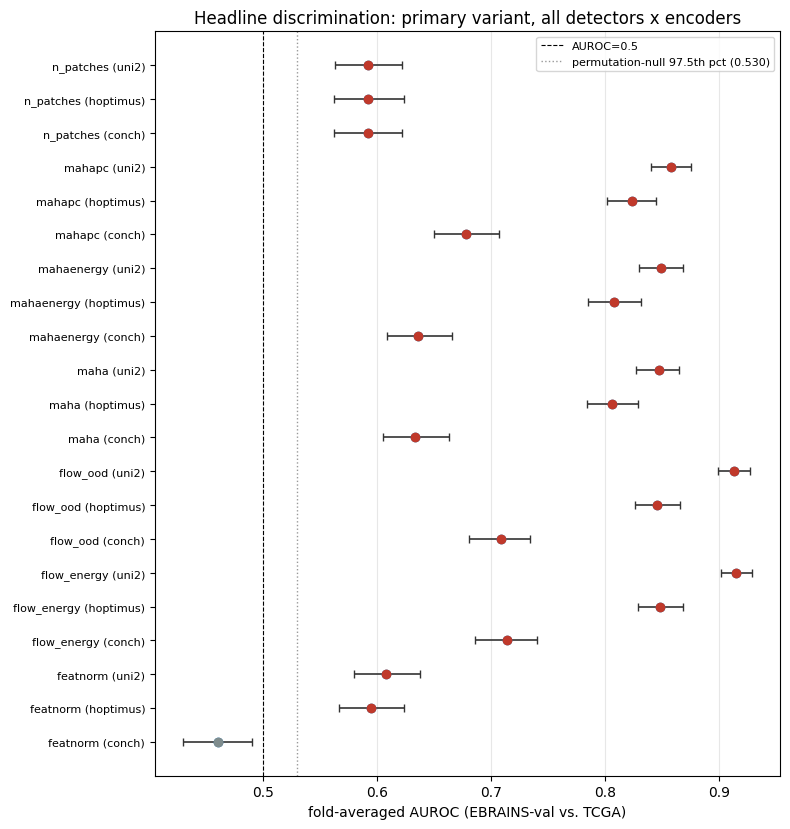

In [31]:
_primary = headline_discrimination[headline_discrimination.apply(
    lambda r: r["variant"] == PRIMARY_VARIANT.get(r["detector"]), axis=1)].copy()
_primary["label"] = _primary["detector"] + " (" + _primary["encoder"] + ")"
_primary = _primary.sort_values(["detector", "encoder"])

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(_primary))))
y_pos = np.arange(len(_primary))
colors = ["#c0392b" if lo > AUROC_SIGNIFICANCE_FLOOR else "#7f8c8d"
          for lo in _primary["auroc_ci_low"]]
ax.errorbar(_primary["auroc"], y_pos,
            xerr=[_primary["auroc"] - _primary["auroc_ci_low"], _primary["auroc_ci_high"] - _primary["auroc"]],
            fmt="o", capsize=3, lw=1.2, ecolor="#333", mfc="none")
for i, c in enumerate(colors):
    ax.scatter(_primary["auroc"].iloc[i], y_pos[i], color=c, zorder=3)
ax.axvline(0.5, color="k", lw=0.8, ls="--", label="AUROC=0.5")
ax.axvline(AUROC_SIGNIFICANCE_FLOOR, color="#999999", lw=1.0, ls=":",
           label=f"permutation-null 97.5th pct ({AUROC_SIGNIFICANCE_FLOOR:.3f})")
ax.set_yticks(y_pos); ax.set_yticklabels(_primary["label"], fontsize=8)
ax.set_xlabel("fold-averaged AUROC (EBRAINS-val vs. TCGA)")
ax.set_title("Headline discrimination: primary variant, all detectors x encoders")
ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

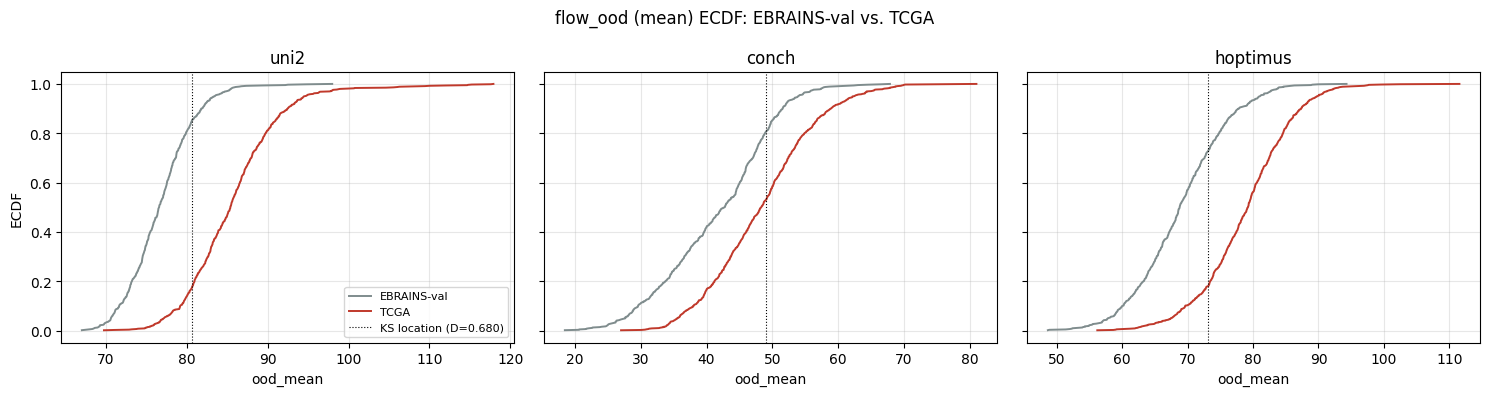

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, enc in zip(axes, ENCODERS):
    hs = hash_single_sample(merged, enc)
    col = DETECTOR_COLUMNS["flow_ood"]["mean"]
    for dataset, label, color in [("ebrains", "EBRAINS-val", "#7f8c8d"), ("tcga", "TCGA", "#c0392b")]:
        x = np.sort(hs.loc[hs.dataset == dataset, col])
        y = np.arange(1, len(x) + 1) / len(x)
        ax.plot(x, y, color=color, lw=1.4, label=label)
    row = distributional_tests[(distributional_tests.encoder == enc) & (distributional_tests.detector == "flow_ood")]
    if len(row) and np.isfinite(row["ks_stat_location"].iloc[0]):
        ax.axvline(row["ks_stat_location"].iloc[0], color="k", lw=0.8, ls=":",
                    label=f"KS location (D={row['ks_stat'].iloc[0]:.3f})")
    ax.set_title(enc); ax.set_xlabel("ood_mean"); ax.grid(alpha=0.3)
axes[0].set_ylabel("ECDF"); axes[0].legend(fontsize=8)
plt.suptitle("flow_ood (mean) ECDF: EBRAINS-val vs. TCGA")
plt.tight_layout(); plt.show()

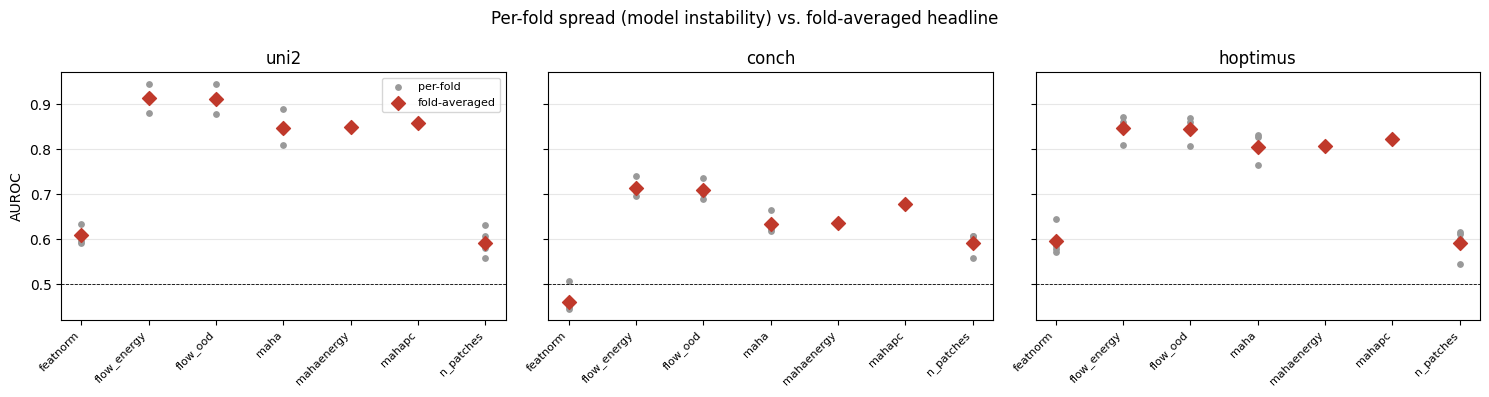

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, enc in zip(axes, ENCODERS):
    pf = per_fold_discrimination[(per_fold_discrimination.encoder == enc) &
                                  (per_fold_discrimination.apply(
                                      lambda r: r["variant"] == PRIMARY_VARIANT.get(r["detector"]), axis=1)) &
                                  (per_fold_discrimination.detector.isin(PRIMARY_DETECTORS))]
    hd = _primary[_primary.encoder == enc]
    dets = hd["detector"].tolist()
    for i, det in enumerate(dets):
        vals = pf.loc[pf.detector == det, "auroc"].to_numpy()
        ax.scatter([i] * len(vals), vals, color="#999999", s=15, zorder=2, label="per-fold" if i == 0 else None)
        ax.scatter([i], hd.loc[hd.detector == det, "auroc"], color="#c0392b", s=50, zorder=3,
                    marker="D", label="fold-averaged" if i == 0 else None)
    ax.set_xticks(range(len(dets))); ax.set_xticklabels(dets, rotation=45, ha="right", fontsize=8)
    ax.set_title(enc); ax.axhline(0.5, color="k", lw=0.6, ls="--"); ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("AUROC"); axes[0].legend(fontsize=8)
plt.suptitle("Per-fold spread (model instability) vs. fold-averaged headline")
plt.tight_layout(); plt.show()

## 8. Subgroup-stratified discrimination

The old notebook only ever asked whether score magnitude varies within
TCGA by subgroup, never whether EBRAINS-vs-TCGA discrimination itself
varies by subgroup, which is the question that actually matters for
understanding what the detector is picking up (is this just detecting
GBM-vs-non-GBM, or does it separate the cohorts equally well within
every tumour type?). This section runs that analysis for the first time,
for every pre-specified primary detector, restricted to
`PRIMARY_DETECTORS` and each detector's primary variant to keep the test
count bounded and pre-specified rather than exploding combinatorially.

Two designs, since the two variable families are structurally different
(Section 2d): `subgroup_discrimination_matched` (8a) handles variables
present in both cohorts (`tumour_type`, `idh_status`, `sex`, `age_band`),
a genuine within-subgroup EBRAINS-vs-TCGA AUROC within each shared
level. Levels below `MIN_GROUP_N` on either side are excluded and
listed, not silently dropped. Each (variable, encoder, detector) also
gets one omnibus heterogeneity permutation test, an n-weighted spread
statistic across that variable's levels, tested against a null built by
shuffling the level label within cohort (preserving cohort marginals and
level counts), rather than many pairwise level contrasts.

In [34]:
merged["age_band"] = pd.cut(
    merged["age"], bins=[0, 20, 40, 55, 70, np.inf],
    labels=["<20", "20-39", "40-54", "55-69", "70+"], right=False,
).astype(str)
merged.loc[merged["age"].isna(), "age_band"] = "nan"

BOTH_COHORT_SUBGROUP_VARS = ["tumour_type", "idh_status", "sex", "age_band"]
TCGA_ONLY_SUBGROUP_VARS = ["site", "objective_power", "model", "race"]
N_PERM_HETEROGENEITY = 300   # reduced from the general N_PERM=2000 for runtime; still
                             # uses the +1/(n+1) continuity correction, so remains a
                             # valid (if slightly coarser-resolution) permutation p-value


def heterogeneity_stat(level_aurocs, level_ns):
    level_aurocs = np.asarray(level_aurocs, dtype=float); level_ns = np.asarray(level_ns, dtype=float)
    valid = np.isfinite(level_aurocs) & (level_ns > 0)
    if valid.sum() < 2:
        return np.nan
    w = level_ns[valid] / level_ns[valid].sum()
    mean = np.sum(w * level_aurocs[valid])
    return float(np.sqrt(np.sum(w * (level_aurocs[valid] - mean) ** 2)))


def stratified_discrimination(merged_df, variable, ebrains_side_fixed=False,
                              detectors=PRIMARY_DETECTORS, min_n=MIN_GROUP_N,
                              n_boot=N_BOOT_SUBGROUP, n_perm=N_PERM_HETEROGENEITY, seed_tag="subgroup"):
    """ebrains_side_fixed=False -> 8a design (both cohorts stratified, matched levels).
    ebrains_side_fixed=True  -> 8b design (TCGA-only variable; EBRAINS side held at
    all cases per fold, only TCGA is stratified and permuted)."""
    result_rows, dropped_rows, het_rows = [], [], []

    for enc in ENCODERS:
        sub = merged_df[merged_df.encoder == enc].copy()
        sub[variable] = sub[variable].astype(str)

        eb_case = sub[sub.dataset == "ebrains"].drop_duplicates("case_id")[["case_id", variable]]
        tg_case = sub[sub.dataset == "tcga"].drop_duplicates("case_id")[["case_id", variable]]
        eb_all_ids = eb_case["case_id"].to_numpy()   # fixed reference side for 8b

        if ebrains_side_fixed:
            tg_counts = tg_case[variable].value_counts()
            levels = sorted([lv for lv in tg_counts.index if tg_counts[lv] >= min_n and lv not in ("nan", "None")])
            dropped_levels = set(tg_counts.index) - set(levels)
            for lv in dropped_levels:
                dropped_rows.append({"variable": variable, "encoder": enc, "level": lv,
                                    "n_ebrains": len(eb_all_ids), "n_tcga": int(tg_counts.get(lv, 0)),
                                    "reason": f"n_tcga < {min_n}"})
        else:
            eb_counts = eb_case[variable].value_counts()
            tg_counts = tg_case[variable].value_counts()
            levels = sorted(set(eb_counts.index) & set(tg_counts.index))
            levels = [lv for lv in levels if eb_counts.get(lv, 0) >= min_n and tg_counts.get(lv, 0) >= min_n
                     and lv not in ("nan", "None")]
            dropped_levels = (set(eb_counts.index) | set(tg_counts.index)) - set(levels)
            for lv in dropped_levels:
                dropped_rows.append({"variable": variable, "encoder": enc, "level": lv,
                                    "n_ebrains": int(eb_counts.get(lv, 0)), "n_tcga": int(tg_counts.get(lv, 0)),
                                    "reason": f"n < {min_n} on at least one side"})

        if len(levels) < 2:
            continue

        for det in detectors:
            col = DETECTOR_COLUMNS[det][PRIMARY_VARIANT[det]]
            level_aurocs, level_ns = [], []
            for lv in levels:
                eb_ids = eb_all_ids if ebrains_side_fixed else eb_case.loc[eb_case[variable] == lv, "case_id"].to_numpy()
                tg_ids = tg_case.loc[tg_case[variable] == lv, "case_id"].to_numpy()
                point = fold_averaged_auroc(sub, col, eb_ids, tg_ids, enc)
                seed = stable_seed(seed_tag, variable, lv, enc, det)
                ci_lo, ci_hi, n_valid, n_dropped = cluster_bootstrap_auroc_ci(
                    sub, col, eb_ids, tg_ids, enc, n_boot=n_boot, seed=seed)
                result_rows.append({"variable": variable, "level": lv, "encoder": enc, "detector": det,
                                    "estimand": "tcga_side_only" if ebrains_side_fixed else "both_sides",
                                    "n_ebrains": len(eb_ids), "n_tcga": len(tg_ids),
                                    "auroc": point, "auroc_ci_low": ci_lo, "auroc_ci_high": ci_hi,
                                    "n_boot_valid": n_valid, "n_boot_dropped": n_dropped})
                level_aurocs.append(point); level_ns.append(len(tg_ids) if ebrains_side_fixed else len(eb_ids) + len(tg_ids))

            observed_stat = heterogeneity_stat(level_aurocs, level_ns)

            rng = np.random.default_rng(stable_seed(seed_tag + "_het_perm", variable, enc, det))
            tg_lv_all = tg_case.loc[tg_case[variable].isin(levels), variable].to_numpy()
            tg_id_all = tg_case.loc[tg_case[variable].isin(levels), "case_id"].to_numpy()
            if not ebrains_side_fixed:
                eb_lv_all = eb_case.loc[eb_case[variable].isin(levels), variable].to_numpy()
                eb_id_all = eb_case.loc[eb_case[variable].isin(levels), "case_id"].to_numpy()

            null_stats = []
            for _ in range(n_perm):
                tg_perm = rng.permutation(tg_lv_all)
                if not ebrains_side_fixed:
                    eb_perm = rng.permutation(eb_lv_all)
                perm_aurocs, perm_ns = [], []
                for lv in levels:
                    tg_ids_p = tg_id_all[tg_perm == lv]
                    eb_ids_p = eb_all_ids if ebrains_side_fixed else eb_id_all[eb_perm == lv]
                    if len(tg_ids_p) < 2 or len(eb_ids_p) < 2:
                        perm_aurocs.append(np.nan); perm_ns.append(0); continue
                    val = fold_averaged_auroc(sub, col, eb_ids_p, tg_ids_p, enc)
                    perm_aurocs.append(val)
                    perm_ns.append(len(tg_ids_p) if ebrains_side_fixed else len(eb_ids_p) + len(tg_ids_p))
                null_stats.append(heterogeneity_stat(perm_aurocs, perm_ns))
            null_stats = np.asarray(null_stats, dtype=float)
            valid_null = null_stats[np.isfinite(null_stats)]
            p_one_sided = (float((np.sum(valid_null >= observed_stat) + 1) / (len(valid_null) + 1))
                          if len(valid_null) and np.isfinite(observed_stat) else np.nan)

            het_rows.append({"variable": variable, "encoder": enc, "detector": det,
                            "estimand": "tcga_side_only" if ebrains_side_fixed else "both_sides",
                            "n_levels": len(levels), "observed_heterogeneity": observed_stat,
                            "p_raw": p_one_sided, "n_perm_valid": len(valid_null)})

    return pd.DataFrame(result_rows), pd.DataFrame(dropped_rows), pd.DataFrame(het_rows)


print("Stratified-discrimination driver defined (shared by 8a and 8b).")

Stratified-discrimination driver defined (shared by 8a and 8b).


In [ ]:
_m_r, _m_h, _m_d = OUT_DIR / "subgroup_discrimination_matched.csv", OUT_DIR / "_het_matched_cache.csv", OUT_DIR / "_dropped_matched_cache.csv"
if _m_r.exists() and _m_h.exists() and _m_d.exists():
    subgroup_discrimination_matched = pd.read_csv(_m_r)
    het_matched = pd.read_csv(_m_h)
    dropped_matched = pd.read_csv(_m_d)
    print(f"Loaded cached 8a results: {len(subgroup_discrimination_matched)} level-level results.")
else:
    _matched_results, _matched_dropped, _matched_het = [], [], []
    for var in BOTH_COHORT_SUBGROUP_VARS:
        r, d, h = stratified_discrimination(merged, var, ebrains_side_fixed=False, seed_tag="matched")
        _matched_results.append(r); _matched_dropped.append(d); _matched_het.append(h)

    subgroup_discrimination_matched = pd.concat(_matched_results, ignore_index=True)
    dropped_matched = pd.concat(_matched_dropped, ignore_index=True)
    het_matched = pd.concat(_matched_het, ignore_index=True)
    het_matched["family"] = "F3"
    het_matched["q"] = bh_fdr(het_matched["p_raw"].to_numpy())
    subgroup_discrimination_matched.to_csv(_m_r, index=False)
    het_matched.to_csv(_m_h, index=False)
    dropped_matched.to_csv(_m_d, index=False)
    print(f"8a (both-cohort variables): {len(subgroup_discrimination_matched)} level-level results, "
          f"{len(dropped_matched)} levels dropped below n={MIN_GROUP_N}.")

display(het_matched.sort_values("p_raw").round(4))

Loaded cached 8a results: 165 level-level results.


,variable,encoder,detector,estimand,n_levels,observed_heterogeneity,p_raw,n_perm_valid,family,q
3,tumour_type,uni2,n_patches,both_sides,3,0.0579,0.0033,300,F3,0.0142
7,tumour_type,conch,maha,both_sides,3,0.0583,0.0033,300,F3,0.0142
6,tumour_type,conch,flow_energy,both_sides,3,0.0489,0.0033,300,F3,0.0142
5,tumour_type,conch,flow_ood,both_sides,3,0.0495,0.0033,300,F3,0.0142
12,tumour_type,hoptimus,maha,both_sides,3,0.0503,0.0033,300,F3,0.0142
10,tumour_type,hoptimus,flow_ood,both_sides,3,0.0446,0.0033,300,F3,0.0142
9,tumour_type,conch,featnorm,both_sides,3,0.0795,0.0033,300,F3,0.0142
8,tumour_type,conch,n_patches,both_sides,3,0.0594,0.0033,300,F3,0.0142
24,idh_status,conch,featnorm,both_sides,2,0.0497,0.0033,300,F3,0.0142
20,idh_status,conch,flow_ood,both_sides,2,0.0518,0.0033,300,F3,0.0142


`stratified_discrimination(..., ebrains_side_fixed=True)` runs the 8b
design for TCGA-only variables (`site`, `objective_power`, `model`,
`race`): the EBRAINS reference side is held fixed at all cases per fold,
and only the TCGA side is stratified/permuted. This is a different
estimand from 8a: it answers "is TCGA subgroup X easier to flag against
a fixed ID reference than subgroup Y," not "does within-subgroup
domain-shift discrimination vary," and is labelled as such in the
`estimand` column rather than mixed into the same table.

In [ ]:
_t_r, _t_h, _t_d = OUT_DIR / "subgroup_discrimination_tcga_side.csv", OUT_DIR / "_het_tcga_cache.csv", OUT_DIR / "_dropped_tcga_cache.csv"
if _t_r.exists() and _t_h.exists() and _t_d.exists():
    subgroup_discrimination_tcga_side = pd.read_csv(_t_r)
    het_tcga_side = pd.read_csv(_t_h)
    dropped_tcga_side = pd.read_csv(_t_d)
    print(f"Loaded cached 8b results: {len(subgroup_discrimination_tcga_side)} level-level results.")
else:
    _tcga_results, _tcga_dropped, _tcga_het = [], [], []
    for var in TCGA_ONLY_SUBGROUP_VARS:
        r, d, h = stratified_discrimination(merged, var, ebrains_side_fixed=True, seed_tag="tcga_side")
        _tcga_results.append(r); _tcga_dropped.append(d); _tcga_het.append(h)

    subgroup_discrimination_tcga_side = pd.concat(_tcga_results, ignore_index=True)
    dropped_tcga_side = pd.concat(_tcga_dropped, ignore_index=True)
    het_tcga_side = pd.concat(_tcga_het, ignore_index=True)
    het_tcga_side["family"] = "F4"
    het_tcga_side["q"] = bh_fdr(het_tcga_side["p_raw"].to_numpy())
    subgroup_discrimination_tcga_side.to_csv(_t_r, index=False)
    het_tcga_side.to_csv(_t_h, index=False)
    dropped_tcga_side.to_csv(_t_d, index=False)
    print(f"8b (TCGA-only variables): {len(subgroup_discrimination_tcga_side)} level-level results, "
          f"{len(dropped_tcga_side)} levels dropped below n={MIN_GROUP_N} "
          f"(e.g. site: {dropped_tcga_side[dropped_tcga_side.variable=='site'].level.nunique()} of "
          f"{merged.loc[merged.dataset=='tcga','site'].nunique()} sites dropped).")

display(het_tcga_side.sort_values("p_raw").round(4))

Loaded cached 8b results: 465 level-level results.


,variable,encoder,detector,estimand,n_levels,observed_heterogeneity,p_raw,n_perm_valid,family,q
0,site,uni2,flow_ood,tcga_side_only,15,0.0338,0.0033,300,F4,0.0057
1,site,uni2,flow_energy,tcga_side_only,15,0.0330,0.0033,300,F4,0.0057
2,site,uni2,maha,tcga_side_only,15,0.0510,0.0033,300,F4,0.0057
3,site,uni2,n_patches,tcga_side_only,15,0.1771,0.0033,300,F4,0.0057
4,site,uni2,featnorm,tcga_side_only,15,0.1421,0.0033,300,F4,0.0057
5,site,conch,flow_ood,tcga_side_only,15,0.1165,0.0033,300,F4,0.0057
6,site,conch,flow_energy,tcga_side_only,15,0.1149,0.0033,300,F4,0.0057
7,site,conch,maha,tcga_side_only,15,0.1127,0.0033,300,F4,0.0057
8,site,conch,n_patches,tcga_side_only,15,0.1770,0.0033,300,F4,0.0057
9,site,conch,featnorm,tcga_side_only,15,0.1544,0.0033,300,F4,0.0057


BH-FDR is applied within F3 and F4 separately (Section 1a); every
dropped group across both designs is consolidated into one disclosure
table so excluded subgroups are visible rather than silently absent.

In [37]:
subgroup_heterogeneity_tests = pd.concat([het_matched, het_tcga_side], ignore_index=True)
dropped_groups = pd.concat([dropped_matched, dropped_tcga_side], ignore_index=True).drop_duplicates()

subgroup_discrimination_matched.to_csv(OUT_DIR / "subgroup_discrimination_matched.csv", index=False)
subgroup_discrimination_tcga_side.to_csv(OUT_DIR / "subgroup_discrimination_tcga_side.csv", index=False)
subgroup_heterogeneity_tests.to_csv(OUT_DIR / "subgroup_heterogeneity_tests.csv", index=False)
dropped_groups.to_csv(OUT_DIR / "dropped_groups.csv", index=False)

print(f"{len(dropped_groups)} (variable, encoder, level) combinations dropped below MIN_GROUP_N={MIN_GROUP_N}:")
display(dropped_groups.groupby(["variable"]).size().rename("n_dropped_level_encoder_combos"))
print(f"\n{int((subgroup_heterogeneity_tests['q'] < 0.05).sum())}/{len(subgroup_heterogeneity_tests)} "
      "heterogeneity tests significant at q<0.05:")
display(subgroup_heterogeneity_tests[subgroup_heterogeneity_tests["q"] < 0.05]
        .sort_values("q")[["variable", "encoder", "detector", "estimand", "n_levels",
                            "observed_heterogeneity", "p_raw", "q"]])

105 (variable, encoder, level) combinations dropped below MIN_GROUP_N=15:


variable
age_band        6
model          24
race            9
sex             6
site           57
tumour_type     3
Name: n_dropped_level_encoder_combos, dtype: int64


59/120 heterogeneity tests significant at q<0.05:


,variable,encoder,detector,estimand,n_levels,observed_heterogeneity,p_raw,q
66,site,conch,flow_energy,tcga_side_only,15,0.114936,0.003322,0.005695
67,site,conch,maha,tcga_side_only,15,0.112694,0.003322,0.005695
73,site,hoptimus,n_patches,tcga_side_only,15,0.177052,0.003322,0.005695
72,site,hoptimus,maha,tcga_side_only,15,0.057301,0.003322,0.005695
69,site,conch,featnorm,tcga_side_only,15,0.154440,0.003322,0.005695
68,site,conch,n_patches,tcga_side_only,15,0.177039,0.003322,0.005695
71,site,hoptimus,flow_energy,tcga_side_only,15,0.051926,0.003322,0.005695
70,site,hoptimus,flow_ood,tcga_side_only,15,0.051875,0.003322,0.005695
62,site,uni2,maha,tcga_side_only,15,0.050981,0.003322,0.005695
63,site,uni2,n_patches,tcga_side_only,15,0.177062,0.003322,0.005695


Plots: two forest panels (8a matched, 8b TCGA-side), CIs always shown,
level `n` printed, rows for a (variable, encoder, detector) with a
significant (q<0.05) heterogeneity test flagged in `#c0392b`.

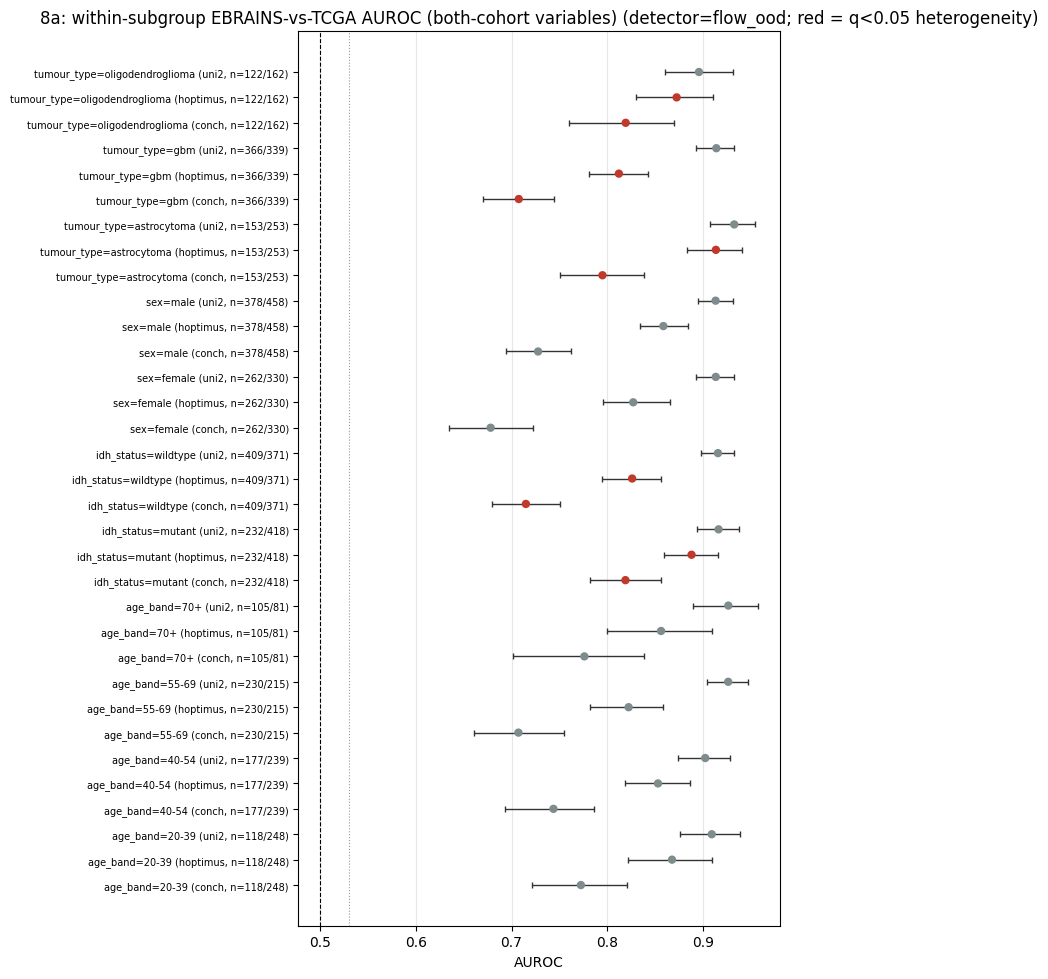

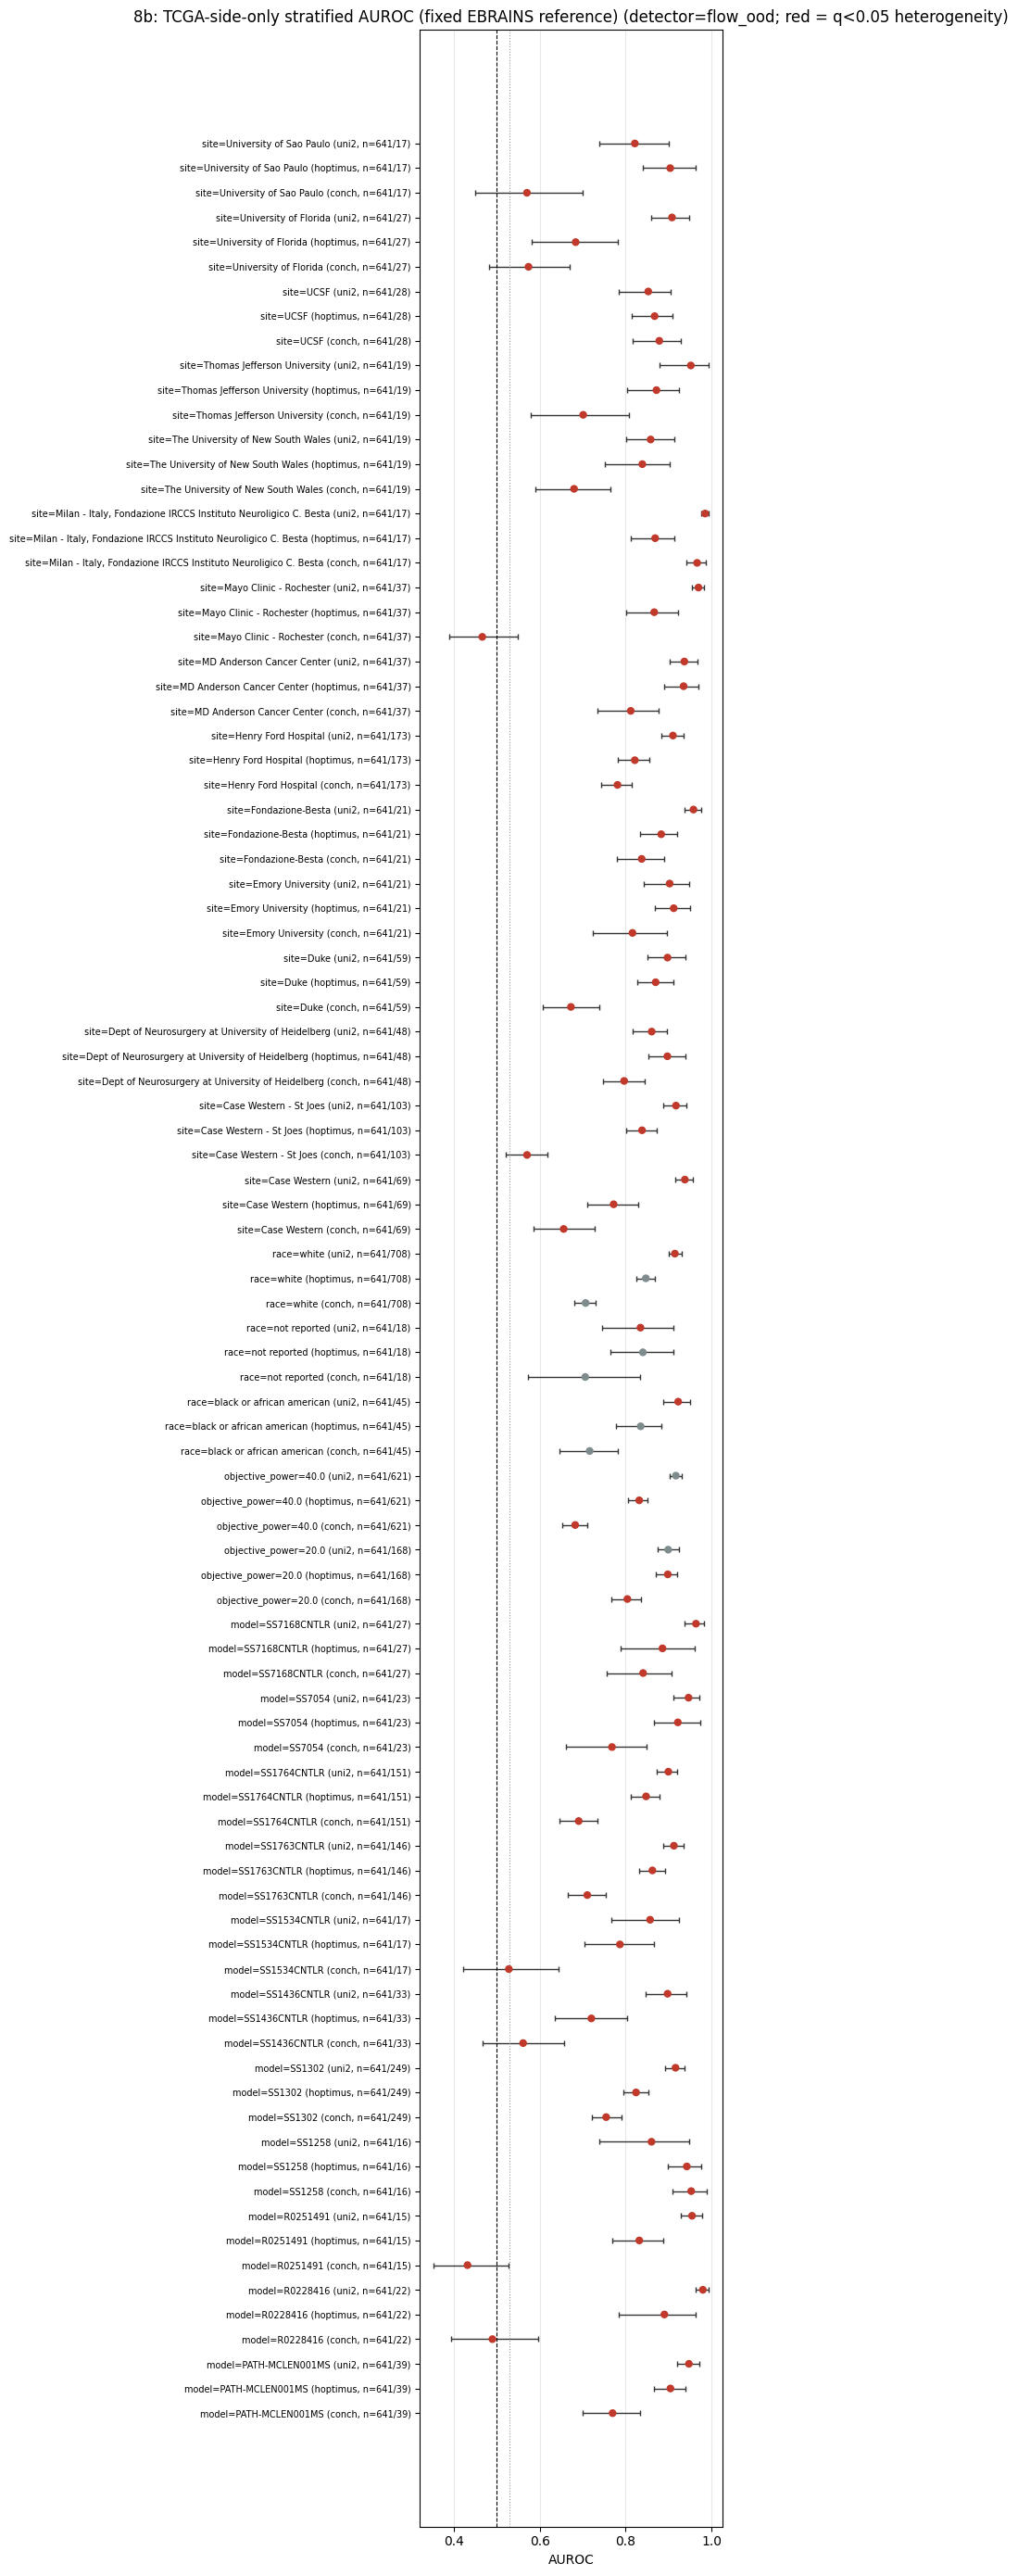

In [38]:
def plot_subgroup_forest(subgroup_df, het_df, title, detector="flow_ood"):
    d = subgroup_df[subgroup_df.detector == detector].copy()
    d["row_label"] = d["variable"] + "=" + d["level"].astype(str) + " (" + d["encoder"] + ", n=" + \
        d["n_ebrains"].astype(str) + "/" + d["n_tcga"].astype(str) + ")"
    d = d.sort_values(["variable", "level", "encoder"])
    sig_pairs = set(
        het_df.loc[(het_df.detector == detector) & (het_df.q < 0.05), ["variable", "encoder"]]
        .apply(tuple, axis=1))
    colors = ["#c0392b" if (v, e) in sig_pairs else "#7f8c8d" for v, e in zip(d["variable"], d["encoder"])]

    fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(d))))
    y_pos = np.arange(len(d))
    ax.errorbar(d["auroc"], y_pos,
                xerr=[d["auroc"] - d["auroc_ci_low"], d["auroc_ci_high"] - d["auroc"]],
                fmt="o", capsize=2, lw=1.0, ecolor="#333", mfc="none", ms=0)
    ax.scatter(d["auroc"], y_pos, color=colors, zorder=3, s=25)
    ax.axvline(0.5, color="k", lw=0.8, ls="--")
    ax.axvline(AUROC_SIGNIFICANCE_FLOOR, color="#999999", lw=0.8, ls=":")
    ax.set_yticks(y_pos); ax.set_yticklabels(d["row_label"], fontsize=7)
    ax.set_xlabel("AUROC"); ax.set_title(f"{title} (detector={detector}; red = q<0.05 heterogeneity)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()

plot_subgroup_forest(subgroup_discrimination_matched, het_matched,
                     "8a: within-subgroup EBRAINS-vs-TCGA AUROC (both-cohort variables)")
plot_subgroup_forest(subgroup_discrimination_tcga_side, het_tcga_side,
                     "8b: TCGA-side-only stratified AUROC (fixed EBRAINS reference)")

## 9. Within-TCGA magnification: a same-vendor natural experiment

Section 4 established that dataset and scanner vendor are perfectly
confounded, so an EBRAINS-vs-TCGA AUROC can't be attributed to tissue
shift vs. scan artifact. TCGA's own internal 40x/20x split (all Aperio,
vendor held fixed) offers a same-vendor, weaker technical perturbation:
how much discrimination does acquisition variation alone produce when
the confound in Section 4 is (partially) controlled for. This is a
lower-bound reference level, not a resolution of that confound, since a
magnification change is a smaller technical perturbation than a full
vendor change.

`tcga_collapsed_scores` averages each TCGA case's score across its 5
fold-duplicated rows (Section 1b's `tcga_collapsed` policy). The
marginal 40x-vs-20x AUROC is reported first, then a within-site
stratified version, since magnification is nested in site (Section 4's
Cramer's V already showed vendor~objective_power association), so the
marginal number may just be a site effect. Combines per-site AUROCs as
an n-weighted average and tests against a site-label-preserving
permutation null.

In [39]:
def tcga_collapsed_scores(merged_df, detector, variant=None):
    col = DETECTOR_COLUMNS[detector][variant or PRIMARY_VARIANT[detector]]
    tcga = merged_df[merged_df.dataset == "tcga"]
    agg = tcga.groupby(["encoder", "case_id"])[col].agg(["mean", "std"]).reset_index()
    agg = agg.rename(columns={"mean": "score", "std": "score_sd_across_folds"})
    meta_cols = ["encoder", "case_id", "site", "objective_power", "model", "mpp_x", "race", "tumour_type"]
    meta_cols += [c for c in ("idh_status", "race_binary") if c in tcga.columns]
    meta = tcga.drop_duplicates(["encoder", "case_id"])[meta_cols]
    return agg.merge(meta, on=["encoder", "case_id"])


def magnification_discrimination(merged_df, detectors=PRIMARY_DETECTORS, n_boot=N_BOOT_SUBGROUP):
    rows = []
    for enc in ENCODERS:
        for det in detectors:
            tc = tcga_collapsed_scores(merged_df[merged_df.encoder == enc], det).dropna(subset=["objective_power"])
            y = (tc["objective_power"] == 20).astype(int).to_numpy()   # 1 = 20x
            s = tc["score"].to_numpy()
            m = binary_ood_metrics(y, s)
            seed = stable_seed("magnification_marginal", enc, det)
            ci_lo, ci_hi, n_valid, n_dropped = bootstrap_auroc_ci(y, s, n_boot=n_boot, seed=seed)
            rows.append({"encoder": enc, "detector": det, "auroc_20x_vs_40x": m["auroc"],
                        "auroc_ci_low": ci_lo, "auroc_ci_high": ci_hi,
                        "n_40x": int((y == 0).sum()), "n_20x": int((y == 1).sum()),
                        "n_boot_valid": n_valid, "n_boot_dropped": n_dropped})
    return pd.DataFrame(rows)

magnification_experiment = magnification_discrimination(merged)
magnification_experiment.to_csv(OUT_DIR / "magnification_experiment.csv", index=False)
display(magnification_experiment.round(4))

,encoder,detector,auroc_20x_vs_40x,auroc_ci_low,auroc_ci_high,n_40x,n_20x,n_boot_valid,n_boot_dropped
0,uni2,flow_ood,0.4421,0.3995,0.4894,621,168,500,0
1,uni2,flow_energy,0.4250,0.3788,0.4746,621,168,500,0
2,uni2,maha,0.4519,0.4055,0.4988,621,168,500,0
3,uni2,n_patches,0.5461,0.5014,0.5915,621,168,500,0
4,uni2,featnorm,0.2884,0.2458,0.3343,621,168,500,0
5,conch,flow_ood,0.6455,0.6030,0.6912,621,168,500,0
6,conch,flow_energy,0.6383,0.5920,0.6855,621,168,500,0
7,conch,maha,0.6539,0.6076,0.7021,621,168,500,0
8,conch,n_patches,0.5461,0.4923,0.5921,621,168,500,0
9,conch,featnorm,0.5582,0.5076,0.6048,621,168,500,0


In [40]:
def weighted_mean(values, weights):
    values = np.asarray(values, float); weights = np.asarray(weights, float)
    valid = np.isfinite(values) & (weights > 0)
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid])) if valid.sum() else np.nan


def magnification_within_site(merged_df, detectors=PRIMARY_DETECTORS, min_per_cell=8, n_perm=N_PERM_HETEROGENEITY):
    rows = []
    for enc in ENCODERS:
        for det in detectors:
            tc = tcga_collapsed_scores(merged_df[merged_df.encoder == enc], det).dropna(subset=["objective_power", "site"])
            ct = pd.crosstab(tc["site"], tc["objective_power"])
            qualifying_sites = ct[(ct.get(40.0, 0) >= min_per_cell) & (ct.get(20.0, 0) >= min_per_cell)].index.tolist()
            if not qualifying_sites:
                rows.append({"encoder": enc, "detector": det, "n_qualifying_sites": 0,
                            "stratified_auroc": np.nan, "p_raw": np.nan, "n_perm_valid": 0})
                continue
            sub = tc[tc.site.isin(qualifying_sites)].reset_index(drop=True)
            y_true = (sub["objective_power"] == 20).astype(int).to_numpy()
            s_true = sub["score"].to_numpy()
            site_arr = sub["site"].to_numpy()

            def stratified_auroc(y, s, sites):
                aurocs, ns = [], []
                for site in qualifying_sites:
                    m = sites == site
                    if len(np.unique(y[m])) < 2:
                        continue
                    aurocs.append(roc_auc_score(y[m], s[m])); ns.append(int(m.sum()))
                return weighted_mean(aurocs, ns)

            observed = stratified_auroc(y_true, s_true, site_arr)
            rng = np.random.default_rng(stable_seed("magnification_within_site", enc, det))
            null = []
            for _ in range(n_perm):
                y_perm = y_true.copy()
                for site in qualifying_sites:
                    m = site_arr == site
                    y_perm[m] = rng.permutation(y_perm[m])
                null.append(stratified_auroc(y_perm, s_true, site_arr))
            null = np.asarray(null, dtype=float)
            valid_null = null[np.isfinite(null)]
            p = (float((np.sum(np.abs(valid_null - 0.5) >= np.abs(observed - 0.5)) + 1) / (len(valid_null) + 1))
                if len(valid_null) and np.isfinite(observed) else np.nan)
            rows.append({"encoder": enc, "detector": det, "n_qualifying_sites": len(qualifying_sites),
                        "stratified_auroc": observed, "p_raw": p, "n_perm_valid": len(valid_null)})
    df = pd.DataFrame(rows)
    df["q"] = bh_fdr(df["p_raw"].fillna(1.0).to_numpy())
    df.loc[df["p_raw"].isna(), "q"] = np.nan
    return df

magnification_within_site_table = magnification_within_site(merged)
magnification_within_site_table.to_csv(OUT_DIR / "magnification_within_site.csv", index=False)
display(magnification_within_site_table.round(4))

,encoder,detector,n_qualifying_sites,stratified_auroc,p_raw,n_perm_valid,q
0,uni2,flow_ood,4,0.4089,0.0066,300,0.0100
1,uni2,flow_energy,4,0.4012,0.0033,300,0.0062
2,uni2,maha,4,0.4270,0.0598,300,0.0641
3,uni2,n_patches,4,0.7409,0.0033,300,0.0062
4,uni2,featnorm,4,0.3900,0.0033,300,0.0062
5,conch,flow_ood,4,0.6073,0.0033,300,0.0062
6,conch,flow_energy,4,0.6044,0.0066,300,0.0100
7,conch,maha,4,0.6263,0.0033,300,0.0062
8,conch,n_patches,4,0.7409,0.0033,300,0.0062
9,conch,featnorm,4,0.4201,0.0365,300,0.0457


In [41]:
from scipy.stats import spearmanr as _spearmanr_mpp

def mpp_continuous_analysis(merged_df, detectors=PRIMARY_DETECTORS):
    rows = []
    for enc in ENCODERS:
        for det in detectors:
            tc = tcga_collapsed_scores(merged_df[merged_df.encoder == enc], det).dropna(subset=["mpp_x"])
            rho_all, p_all = _spearmanr_mpp(tc["mpp_x"], tc["score"])
            tc40 = tc[tc.objective_power == 40]
            rho_40, p_40 = (_spearmanr_mpp(tc40["mpp_x"], tc40["score"]) if len(tc40) > 10 else (np.nan, np.nan))
            rows.append({"encoder": enc, "detector": det, "n_all": len(tc), "n_40x": len(tc40),
                        "spearman_rho_all": float(rho_all), "p_all": float(p_all),
                        "spearman_rho_40x_only": float(rho_40) if np.isfinite(rho_40) else np.nan,
                        "p_40x_only": float(p_40) if np.isfinite(p_40) else np.nan})
    return pd.DataFrame(rows)

mpp_continuous_table = mpp_continuous_analysis(merged)
display(mpp_continuous_table.round(4))

,encoder,detector,n_all,n_40x,spearman_rho_all,p_all,spearman_rho_40x_only,p_40x_only
0,uni2,flow_ood,789,621,-0.1070,0.0026,-0.0723,0.0718
1,uni2,flow_energy,789,621,-0.1260,0.0004,-0.0758,0.0590
2,uni2,maha,789,621,-0.0856,0.0162,-0.0600,0.1352
3,uni2,n_patches,789,621,-0.0031,0.9312,-0.0589,0.1426
4,uni2,featnorm,789,621,-0.2683,0.0000,-0.1043,0.0093
5,conch,flow_ood,789,621,0.2487,0.0000,0.1623,0.0000
6,conch,flow_energy,789,621,0.2430,0.0000,0.1646,0.0000
7,conch,maha,789,621,0.2518,0.0000,0.1563,0.0001
8,conch,n_patches,789,621,-0.0031,0.9312,-0.0589,0.1426
9,conch,featnorm,789,621,-0.0093,0.7941,-0.1097,0.0062


## 10. Variance decomposition: acquisition vs. biology

Extends the bench notebook's own limited `signal_structure` function,
which computed variance-explained-by-site for entropy/MI/OOD signals
without a null, into a proper comparison of how much score variance is
explained by acquisition variables vs. biological/clinical variables
within TCGA, each judged against its own permutation null (eta-squared
is upward-biased with many small groups, e.g. the 34-level `site`
variable, so a null is required, not just the raw statistic).

`variance_decomposition` computes eta-squared (SS-between / SS-total) of
the primary score by each grouping, on `tcga_collapsed` scores, with a
label-permutation null per (encoder, detector, grouping), family F6,
BH-FDR corrected.

In [42]:
def to_race_binary(value):
    value = str(value).strip().lower()
    if value in ("", "nan", "none", "not reported", "unknown", "not available"):
        return np.nan
    return "white" if value == "white" else "non-white"

merged["race_binary"] = merged["race"].apply(to_race_binary)

ACQUISITION_GROUPINGS = ["site", "objective_power", "model"]
BIOLOGY_GROUPINGS = ["tumour_type", "idh_status", "race_binary"]
VARIANCE_GROUPINGS = ACQUISITION_GROUPINGS + BIOLOGY_GROUPINGS


def eta_squared(values, groups):
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)
    grand_mean = values.mean()
    ss_total = np.sum((values - grand_mean) ** 2)
    if ss_total == 0:
        return np.nan
    ss_between = sum(
        (groups == g).sum() * (values[groups == g].mean() - grand_mean) ** 2
        for g in np.unique(groups)
    )
    return float(ss_between / ss_total)


def variance_decomposition(merged_df, group_cols=VARIANCE_GROUPINGS, detectors=PRIMARY_DETECTORS,
                           n_perm=N_PERM_HETEROGENEITY, min_group_n=MIN_GROUP_N):
    rows = []
    for enc in ENCODERS:
        for det in detectors:
            tc = tcga_collapsed_scores(merged_df[merged_df.encoder == enc], det)
            for gcol in group_cols:
                sub = tc.dropna(subset=[gcol])
                counts = sub[gcol].value_counts()
                sub = sub[sub[gcol].isin(counts[counts >= min_group_n].index)]
                if sub[gcol].nunique() < 2 or len(sub) < 10:
                    continue
                s, g = sub["score"].to_numpy(), sub[gcol].to_numpy()
                observed = eta_squared(s, g)
                rng = np.random.default_rng(stable_seed("eta2", enc, det, gcol))
                null = np.array([eta_squared(s, rng.permutation(g)) for _ in range(n_perm)])
                valid_null = null[np.isfinite(null)]
                p = float((np.sum(valid_null >= observed) + 1) / (len(valid_null) + 1)) if len(valid_null) else np.nan
                rows.append({"encoder": enc, "detector": det, "grouping": gcol,
                            "family": "acquisition" if gcol in ACQUISITION_GROUPINGS else "biology",
                            "n_levels": int(sub[gcol].nunique()), "n": len(sub),
                            "eta_squared": observed, "p_raw": p, "n_perm_valid": len(valid_null)})
    df = pd.DataFrame(rows)
    df["q"] = bh_fdr(df["p_raw"].to_numpy())
    return df

variance_decomposition_table = variance_decomposition(merged)
display(variance_decomposition_table.sort_values("eta_squared", ascending=False).round(4).head(15))

,encoder,detector,grouping,family,n_levels,n,eta_squared,p_raw,n_perm_valid,q
18,uni2,n_patches,site,acquisition,15,695,0.3563,0.0033,300,0.006
48,conch,n_patches,site,acquisition,15,695,0.3563,0.0033,300,0.006
78,hoptimus,n_patches,site,acquisition,15,695,0.3563,0.0033,300,0.006
87,hoptimus,featnorm,tumour_type,biology,4,789,0.2891,0.0033,300,0.006
24,uni2,featnorm,site,acquisition,15,695,0.2763,0.0033,300,0.006
84,hoptimus,featnorm,site,acquisition,15,695,0.2680,0.0033,300,0.006
54,conch,featnorm,site,acquisition,15,695,0.2668,0.0033,300,0.006
88,hoptimus,featnorm,idh_status,biology,2,789,0.2537,0.0033,300,0.006
86,hoptimus,featnorm,model,acquisition,11,738,0.2301,0.0033,300,0.006
30,conch,flow_ood,site,acquisition,15,695,0.1862,0.0033,300,0.006


The quantitative version of Section 4's confound argument:
eta-squared(`dataset`) on the `hash_single` i.i.d. sample, next to the
largest within-TCGA acquisition and biology eta-squared values, showing
how big the cross-cohort effect is relative to effects already known to
be purely acquisition-driven or purely biology-driven.

In [43]:
def dataset_eta_squared(merged_df, detectors=PRIMARY_DETECTORS):
    rows = []
    for enc in ENCODERS:
        for det in detectors:
            hs = hash_single_sample(merged_df, enc)
            col = DETECTOR_COLUMNS[det][PRIMARY_VARIANT[det]]
            observed = eta_squared(hs[col].astype(float).to_numpy(), hs["dataset"].to_numpy())
            rows.append({"encoder": enc, "detector": det, "grouping": "dataset (EBRAINS vs TCGA)",
                        "family": "cohort", "n_levels": 2, "n": len(hs), "eta_squared": observed})
    return pd.DataFrame(rows)

dataset_eta = dataset_eta_squared(merged)

_compare_eta = pd.concat([
    dataset_eta,
    variance_decomposition_table[variance_decomposition_table.family == "acquisition"]
        .sort_values("eta_squared", ascending=False).groupby(["encoder", "detector"]).head(1),
    variance_decomposition_table[variance_decomposition_table.family == "biology"]
        .sort_values("eta_squared", ascending=False).groupby(["encoder", "detector"]).head(1),
], ignore_index=True)
display(_compare_eta.pivot_table(index=["encoder", "detector"], columns="family", values="eta_squared").round(4))

variance_decomposition_table = pd.concat([variance_decomposition_table, dataset_eta], ignore_index=True)
variance_decomposition_table.to_csv(OUT_DIR / "variance_decomposition.csv", index=False)

family                acquisition  biology  cohort
encoder  detector                                 
conch    featnorm          0.2668   0.0617  0.0049
         flow_energy       0.1820   0.0793  0.1498
         flow_ood          0.1862   0.0868  0.1440
         maha              0.1427   0.0947  0.0574
         n_patches         0.3563   0.0075  0.0264
hoptimus featnorm          0.2680   0.2891  0.0212
         flow_energy       0.0778   0.0076  0.3383
         flow_ood          0.0772   0.0084  0.3343
         maha              0.0713   0.0065  0.2421
         n_patches         0.3563   0.0075  0.0264
uni2     featnorm          0.2763   0.1574  0.0371
         flow_energy       0.0893   0.0256  0.4266
         flow_ood          0.0881   0.0281  0.4239
         maha              0.0854   0.0266  0.2830
         n_patches         0.3563   0.0075  0.0264

The within-TCGA magnitude-contrast battery from the old notebook,
retained but now BH-FDR corrected, `MIN_GROUP_N=15`, sorted by q (never
raw p), with `brain_region` already excluded (Section 2d: constant,
zero information). Two-group contrasts use Mann-Whitney U (with
rank-biserial effect size); >2-group contrasts use Kruskal-Wallis (no
natural single effect size, left blank).

In [44]:
from scipy.stats import mannwhitneyu, kruskal

def rank_biserial_from_u(u, n1, n2):
    return float(2 * u / (n1 * n2) - 1)


def tcga_magnitude_contrasts(merged_df, group_cols=VARIANCE_GROUPINGS, detectors=PRIMARY_DETECTORS, min_n=MIN_GROUP_N):
    rows = []
    for enc in ENCODERS:
        for det in detectors:
            tc = tcga_collapsed_scores(merged_df[merged_df.encoder == enc], det)
            for gcol in group_cols:
                sub = tc.dropna(subset=[gcol])
                counts = sub[gcol].value_counts()
                sub = sub[sub[gcol].isin(counts[counts >= min_n].index)]
                levels = sub[gcol].unique().tolist()
                if len(levels) < 2:
                    continue
                groups = [sub.loc[sub[gcol] == lv, "score"].to_numpy() for lv in levels]
                if len(levels) == 2:
                    u, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
                    effect, test = rank_biserial_from_u(u, len(groups[0]), len(groups[1])), "mannwhitneyu"
                else:
                    _, p = kruskal(*groups)
                    effect, test = np.nan, "kruskal"
                rows.append({"encoder": enc, "detector": det, "variable": gcol, "test": test,
                            "n_levels": len(levels), "levels": levels, "n_total": len(sub),
                            "p_raw": float(p), "rank_biserial": effect, "family": "F5"})
    df = pd.DataFrame(rows)
    df["q"] = bh_fdr(df["p_raw"].to_numpy())
    return df.sort_values("q").reset_index(drop=True)

tcga_magnitude_contrasts_table = tcga_magnitude_contrasts(merged)
tcga_magnitude_contrasts_table.to_csv(OUT_DIR / "tcga_magnitude_contrasts.csv", index=False)
display(tcga_magnitude_contrasts_table.drop(columns=["levels"]).round(4).head(20))

,encoder,detector,variable,test,n_levels,n_total,p_raw,rank_biserial,family,q
0,hoptimus,featnorm,tumour_type,kruskal,4,789,0.0,NaN,F5,0.0
1,uni2,n_patches,site,kruskal,15,695,0.0,NaN,F5,0.0
2,hoptimus,n_patches,site,kruskal,15,695,0.0,NaN,F5,0.0
3,conch,n_patches,site,kruskal,15,695,0.0,NaN,F5,0.0
4,hoptimus,featnorm,idh_status,mannwhitneyu,2,789,0.0,-0.5856,F5,0.0
5,uni2,featnorm,site,kruskal,15,695,0.0,NaN,F5,0.0
6,hoptimus,featnorm,site,kruskal,15,695,0.0,NaN,F5,0.0
7,hoptimus,featnorm,objective_power,mannwhitneyu,2,789,0.0,-0.5919,F5,0.0
8,hoptimus,featnorm,model,kruskal,11,738,0.0,NaN,F5,0.0
9,conch,featnorm,site,kruskal,15,695,0.0,NaN,F5,0.0


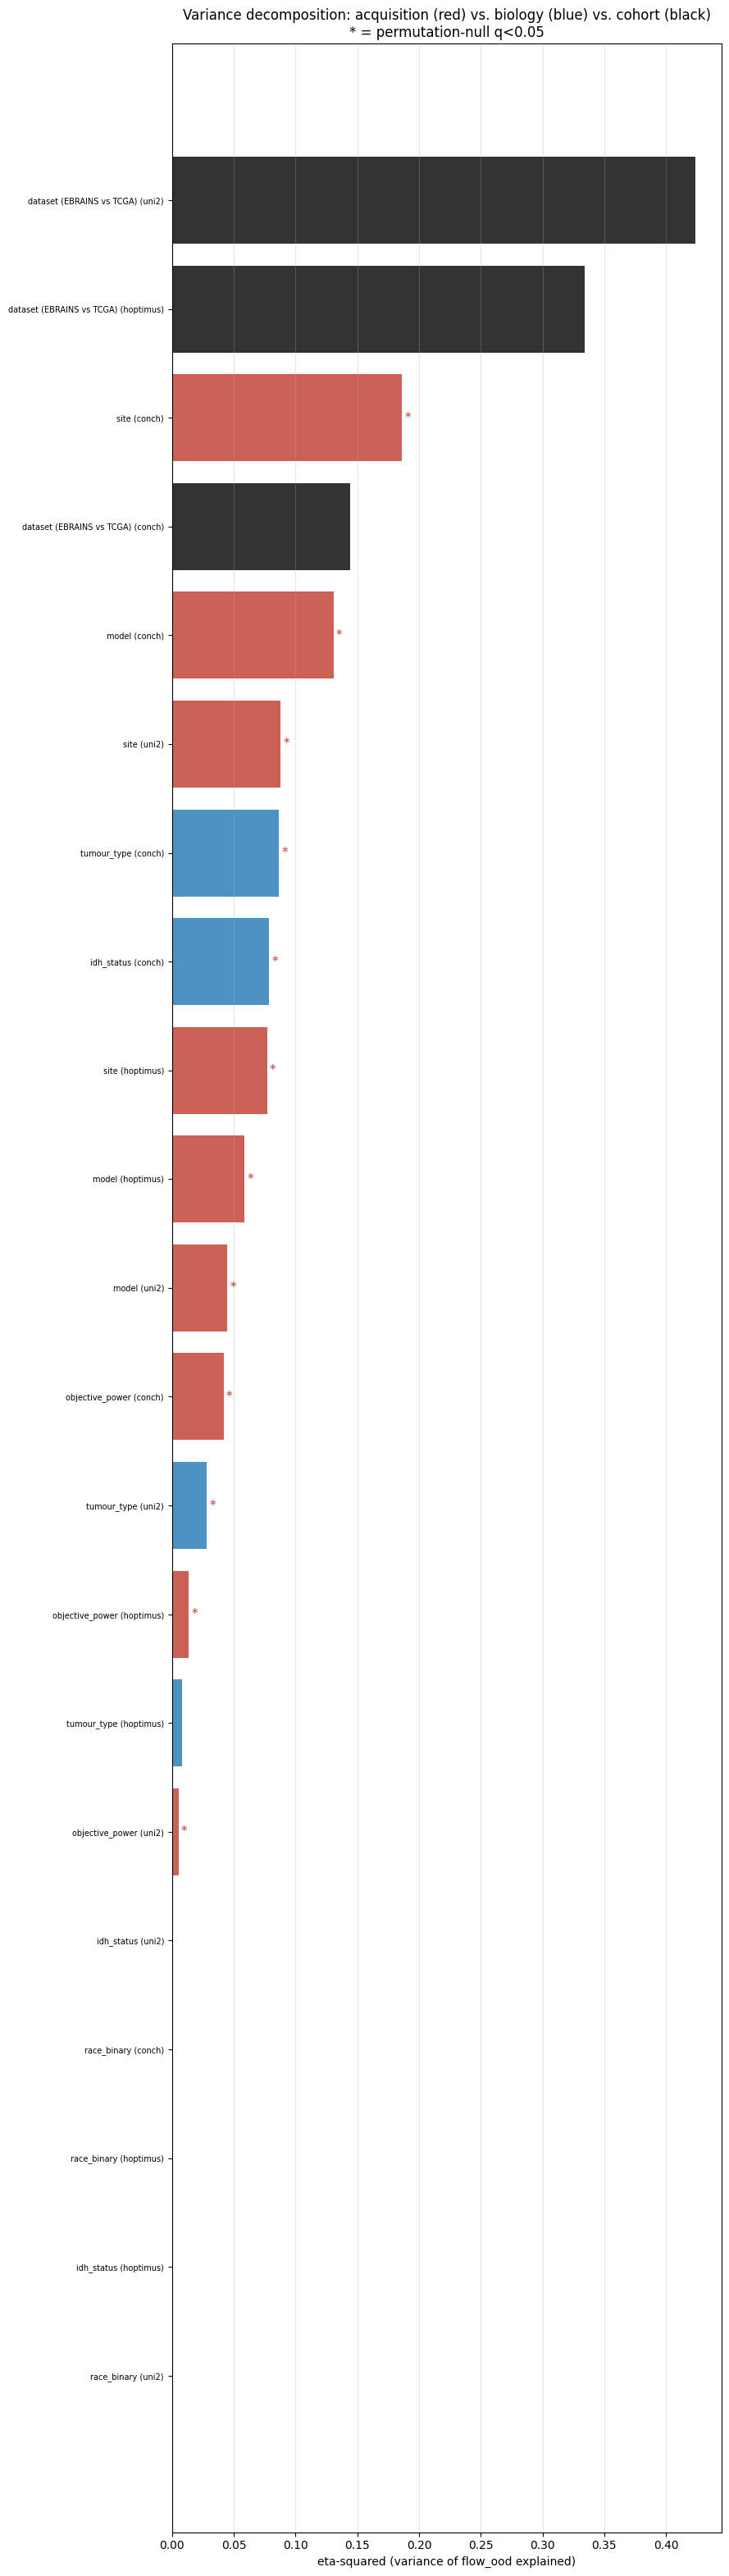

In [45]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(variance_decomposition_table))))
d = variance_decomposition_table[variance_decomposition_table.detector == "flow_ood"].copy()
d["label"] = d["grouping"] + " (" + d["encoder"] + ")"
d = d.sort_values("eta_squared")
colors = {"acquisition": "#c0392b", "biology": "tab:blue", "cohort": "black"}
y_pos = np.arange(len(d))
ax.barh(y_pos, d["eta_squared"], color=[colors[f] for f in d["family"]], alpha=0.8)
for i, (_, row) in enumerate(d.iterrows()):
    if row["family"] != "cohort" and np.isfinite(row.get("q", np.nan)) and row["q"] < 0.05:
        ax.text(row["eta_squared"] + 0.002, i, "*", va="center", fontsize=11, color="#c0392b")
ax.set_yticks(y_pos); ax.set_yticklabels(d["label"], fontsize=7)
ax.set_xlabel("eta-squared (variance of flow_ood explained)")
ax.set_title("Variance decomposition: acquisition (red) vs. biology (blue) vs. cohort (black)\n"
             "* = permutation-null q<0.05")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Density-classification sanity check

If the three class-conditional flows can't actually distinguish
gbm/astrocytoma/oligodendroglioma on held-out EBRAINS patients, then
`-max_k log p(z|k)` is a generic feature-density monitor, not a
tumour-biology-aware one, which would change how every AUROC in Sections
7-10 should be read. Checked directly rather than assumed.

`density_classification` uses the already-cached
`density_predicted_class`/`density_prob_*` columns (EBRAINS-val only) to
report accuracy, balanced accuracy, macro one-vs-rest AUROC, and
per-class OVR AUROC with bootstrap CIs, both per-fold and pooled across
all 641 patients. Pooling here is not pseudo-replication: unlike TCGA,
each of the 641 EBRAINS patients appears in exactly one fold (Section
2), so a single pooled confusion matrix per encoder is legitimate in a
way nothing on the TCGA side is.

In [46]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score

def density_classification(scores_df, n_boot=N_BOOT_SUBGROUP):
    rows = []
    conf_matrices = {}
    prob_cols = [f"density_prob_{c}" for c in CLASS_NAMES]

    for enc in ENCODERS:
        eb = scores_df[(scores_df.dataset == "ebrains") & (scores_df.encoder == enc)].copy()
        eb = eb.dropna(subset=["tumour_class", "density_predicted_class"] + prob_cols)
        y_true = eb["tumour_class"].astype(int).to_numpy()
        y_pred = eb["density_predicted_class"].astype(int).to_numpy()
        probs = eb[prob_cols].to_numpy()

        for f in FOLDS:
            m = (eb["fold"] == f).to_numpy()
            if m.sum() < 5:
                continue
            yt, yp, pr = y_true[m], y_pred[m], probs[m]
            try:
                macro_auc = roc_auc_score(yt, pr, multi_class="ovr", average="macro")
            except ValueError:
                macro_auc = np.nan
            rows.append({"encoder": enc, "fold": f, "scope": "per_fold", "n": int(m.sum()),
                        "accuracy": accuracy_score(yt, yp), "balanced_accuracy": balanced_accuracy_score(yt, yp),
                        "macro_ovr_auroc": macro_auc})

        try:
            macro_auc = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        except ValueError:
            macro_auc = np.nan
        row = {"encoder": enc, "fold": -1, "scope": "pooled_641", "n": len(y_true),
               "accuracy": accuracy_score(y_true, y_pred), "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
               "macro_ovr_auroc": macro_auc}
        for ci, cname in enumerate(CLASS_NAMES):
            yb, sb = (y_true == ci).astype(int), probs[:, ci]
            auc_c = roc_auc_score(yb, sb)
            seed = stable_seed("density_ovr", enc, cname)
            ci_lo, ci_hi, n_valid, n_dropped = bootstrap_auroc_ci(yb, sb, n_boot=n_boot, seed=seed)
            row[f"ovr_auroc_{cname}"] = auc_c
            row[f"ovr_auroc_{cname}_ci_low"], row[f"ovr_auroc_{cname}_ci_high"] = ci_lo, ci_hi
        rows.append(row)

        conf_matrices[enc] = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    return pd.DataFrame(rows), conf_matrices

density_classification_table, density_conf_matrices = density_classification(scores)
density_classification_table.to_csv(OUT_DIR / "density_classification.csv", index=False)
display(density_classification_table[density_classification_table.scope == "pooled_641"].round(3))

,encoder,fold,scope,n,accuracy,balanced_accuracy,macro_ovr_auroc,ovr_auroc_gbm,ovr_auroc_gbm_ci_low,ovr_auroc_gbm_ci_high,ovr_auroc_astrocytoma,ovr_auroc_astrocytoma_ci_low,ovr_auroc_astrocytoma_ci_high,ovr_auroc_oligodendroglioma,ovr_auroc_oligodendroglioma_ci_low,ovr_auroc_oligodendroglioma_ci_high
5,uni2,-1,pooled_641,641,0.827,0.764,0.939,0.952,0.936,0.965,0.902,0.871,0.930,0.963,0.949,0.976
11,conch,-1,pooled_641,641,0.803,0.725,0.926,0.943,0.925,0.959,0.889,0.858,0.916,0.945,0.921,0.967
17,hoptimus,-1,pooled_641,641,0.817,0.733,0.931,0.950,0.934,0.966,0.897,0.866,0.923,0.944,0.923,0.963


The confusion matrix the old notebook imported `confusion_matrix` for
but never drew, despite reporting accuracy/balanced-accuracy without
it.

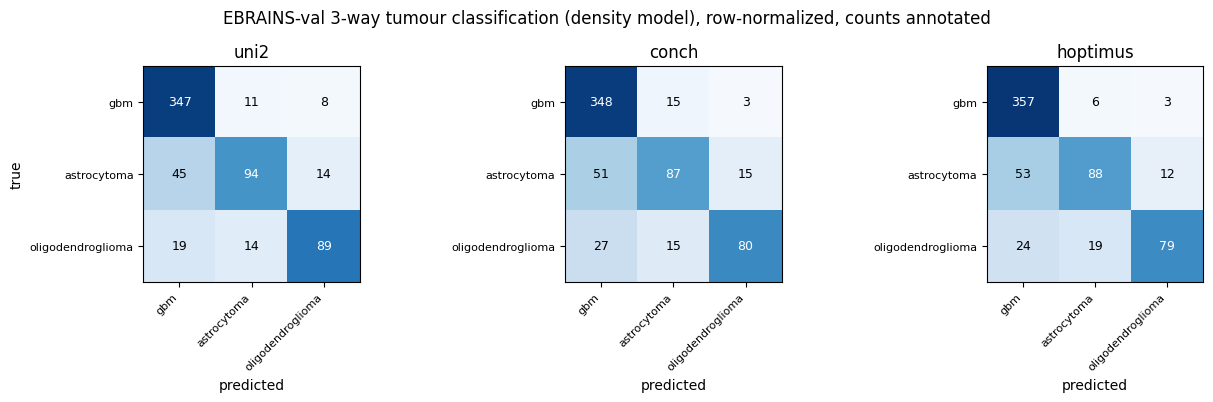

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, enc in zip(axes, ENCODERS):
    cm = density_conf_matrices[enc]
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=9)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_title(enc)
axes[0].set_ylabel("true")
plt.suptitle("EBRAINS-val 3-way tumour classification (density model), row-normalized, counts annotated")
plt.tight_layout(); plt.show()

Descriptive only (3 points, one per encoder, no test fitted): does an
encoder whose density model separates tumour classes better also
separate EBRAINS from TCGA better?

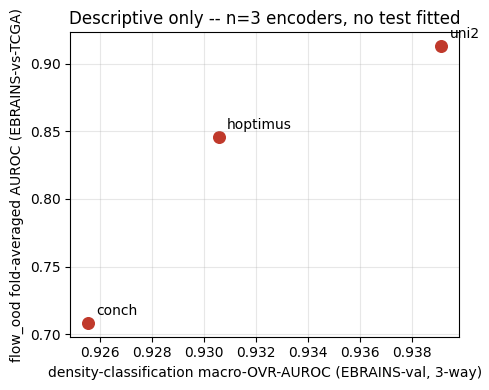

,encoder,macro_ovr_auroc,auroc
0,uni2,0.9391,0.9130
1,conch,0.9255,0.7084
2,hoptimus,0.9306,0.8457


In [48]:
_density_pooled = density_classification_table[density_classification_table.scope == "pooled_641"][
    ["encoder", "macro_ovr_auroc"]]
_ood_headline = headline_discrimination[
    (headline_discrimination.detector == "flow_ood") & (headline_discrimination.variant == "mean")][
    ["encoder", "auroc"]]
_scatter_df = _density_pooled.merge(_ood_headline, on="encoder", suffixes=("_density", "_ood"))

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(_scatter_df["macro_ovr_auroc"], _scatter_df["auroc"], s=70, color="#c0392b")
for _, r in _scatter_df.iterrows():
    ax.annotate(r["encoder"], (r["macro_ovr_auroc"], r["auroc"]), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("density-classification macro-OVR-AUROC (EBRAINS-val, 3-way)")
ax.set_ylabel("flow_ood fold-averaged AUROC (EBRAINS-vs-TCGA)")
ax.set_title("Descriptive only -- n=3 encoders, no test fitted")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
display(_scatter_df.round(4))

## 12. Summary and limitations

One row per (encoder, detector): headline AUROC + CI, delta vs. the
two trivial baselines, delta flow-minus-maha, the KS test, the
bag-size-matched AUROC, the magnification reference level, and the
smallest subgroup-heterogeneity q-value, everything needed to read the
notebook's conclusion off one table.

In [49]:
def build_summary_headline():
    base = headline_discrimination[headline_discrimination.apply(
        lambda r: r["variant"] == PRIMARY_VARIANT.get(r["detector"]), axis=1)][
        ["encoder", "detector", "auroc", "auroc_ci_low", "auroc_ci_high", "fold_sd_model_instability"]].copy()

    for baseline in ["n_patches", "featnorm"]:
        d = paired_detector_comparison[paired_detector_comparison.detector_b == baseline][
            ["encoder", "detector_a", "delta", "q"]].rename(
            columns={"detector_a": "detector", "delta": f"delta_vs_{baseline}", "q": f"q_vs_{baseline}"})
        base = base.merge(d, on=["encoder", "detector"], how="left")

    fm = paired_detector_comparison[
        (paired_detector_comparison.detector_a == "flow_ood") & (paired_detector_comparison.detector_b == "maha")][
        ["encoder", "delta", "q"]].rename(columns={"delta": "delta_flow_minus_maha", "q": "q_flow_minus_maha"})
    base = base.merge(fm, on="encoder", how="left")

    ks = distributional_tests[["encoder", "detector", "ks_stat", "q"]].rename(columns={"q": "q_ks"})
    base = base.merge(ks, on=["encoder", "detector"], how="left")

    bm = bagsize_matched_discrimination_table[["encoder", "detector", "matched_auroc"]]
    base = base.merge(bm, on=["encoder", "detector"], how="left")

    mag = magnification_experiment[["encoder", "detector", "auroc_20x_vs_40x"]]
    base = base.merge(mag, on=["encoder", "detector"], how="left")

    het_min = (subgroup_heterogeneity_tests[subgroup_heterogeneity_tests.estimand == "both_sides"]
              .groupby(["encoder", "detector"])["q"].min().rename("min_subgroup_heterogeneity_q").reset_index())
    base = base.merge(het_min, on=["encoder", "detector"], how="left")

    return base

summary_headline = build_summary_headline()
summary_headline.to_csv(OUT_DIR / "summary_headline.csv", index=False)
display(summary_headline.round(4))

,encoder,detector,auroc,auroc_ci_low,auroc_ci_high,fold_sd_model_instability,delta_vs_n_patches,q_vs_n_patches,delta_vs_featnorm,q_vs_featnorm,delta_flow_minus_maha,q_flow_minus_maha,ks_stat,q_ks,matched_auroc,auroc_20x_vs_40x,min_subgroup_heterogeneity_q
0,uni2,flow_ood,0.9130,0.8988,0.9267,0.0211,0.3207,0.0011,0.3048,0.0011,0.0657,0.0011,0.6797,0.0000,0.9108,0.4421,0.4140
1,uni2,flow_energy,0.9146,0.9011,0.9283,0.0214,NaN,NaN,NaN,NaN,0.0657,0.0011,0.6849,0.0000,0.9132,0.4250,0.4140
2,uni2,maha,0.8473,0.8269,0.8650,0.0253,0.2550,0.0011,0.2391,0.0011,0.0657,0.0011,0.5523,0.0000,0.8426,0.4519,0.2421
3,uni2,mahapc,0.8581,0.8398,0.8750,0.0265,NaN,NaN,NaN,NaN,0.0657,0.0011,0.5631,NaN,NaN,NaN,NaN
4,uni2,mahaenergy,0.8490,0.8294,0.8684,0.0251,NaN,NaN,NaN,NaN,0.0657,0.0011,0.5489,NaN,NaN,NaN,NaN
5,uni2,n_patches,0.5923,0.5636,0.6220,0.0253,NaN,NaN,NaN,NaN,0.0657,0.0011,0.1333,0.0000,0.5008,0.5461,0.0142
6,uni2,featnorm,0.6082,0.5795,0.6374,0.0149,NaN,NaN,NaN,NaN,0.0657,0.0011,0.1821,0.0000,0.6016,0.2884,0.0235
7,conch,flow_ood,0.7084,0.6809,0.7342,0.0152,0.1161,0.0011,0.2475,0.0011,0.0749,0.0011,0.2780,0.0000,0.7049,0.6455,0.0142
8,conch,flow_energy,0.7136,0.6863,0.7405,0.0152,NaN,NaN,NaN,NaN,0.0749,0.0011,0.2872,0.0000,0.7088,0.6383,0.0142
9,conch,maha,0.6334,0.6054,0.6628,0.0168,0.0411,0.0600,0.1726,0.0011,0.0749,0.0011,0.2015,0.0000,0.6259,0.6539,0.0142


## 13. Saved artifacts

In [50]:
saved = sorted(p.name for p in OUT_DIR.glob("*.csv") if not p.name.startswith("_"))
print(f"{len(saved)} artifacts saved to {OUT_DIR} "
      "(internal _*.csv caches used to speed up re-runs are excluded from this list):")
for name in saved:
    print(" ", name)

28 artifacts saved to /cs/student/project_msc/2025/aibh/mpapageo/outputs/ood_evaluation_analysis (internal _*.csv caches used to speed up re-runs are excluded from this list):
  acquisition_confound_table.csv
  acquisition_mpp_summary.csv
  bagsize_comparison.csv
  bagsize_matched_discrimination.csv
  bagsize_sensitivity.csv
  confound_cramers_v.csv
  density_classification.csv
  distributional_tests.csv
  dropped_groups.csv
  headline_discrimination.csv
  magnification_experiment.csv
  magnification_within_site.csv
  maha_case_scores.csv
  maha_reference_report.csv
  maha_runtime_log.csv
  merged_case_scores.csv
  paired_detector_comparison.csv
  per_fold_discrimination.csv
  row_structure_audit.csv
  split_integrity_audit.csv
  subgroup_discrimination_matched.csv
  subgroup_discrimination_tcga_side.csv
  subgroup_heterogeneity_tests.csv
  summary_headline.csv
  tcga_magnitude_contrasts.csv
  variable_availability.csv
  variance_decomposition.csv
  variant_sensitivity.csv
